# 1. 서론

## 1.1 데이터셋 목록
#### 1. PSID 데이터셋 
https://www.openicpsr.org/openicpsr/project/194322/version/V2/view;jsessionid=601A71B8C00373A9B14A620A05BA96F8
#### 2. Home-Credit 데이터셋
https://www.kaggle.com/competitions/home-credit-default-risk/data?select=HomeCredit_columns_description.csv

## 1.2 건강 데이터와 상환수행능력, 경제활동과의 상관관계 분석

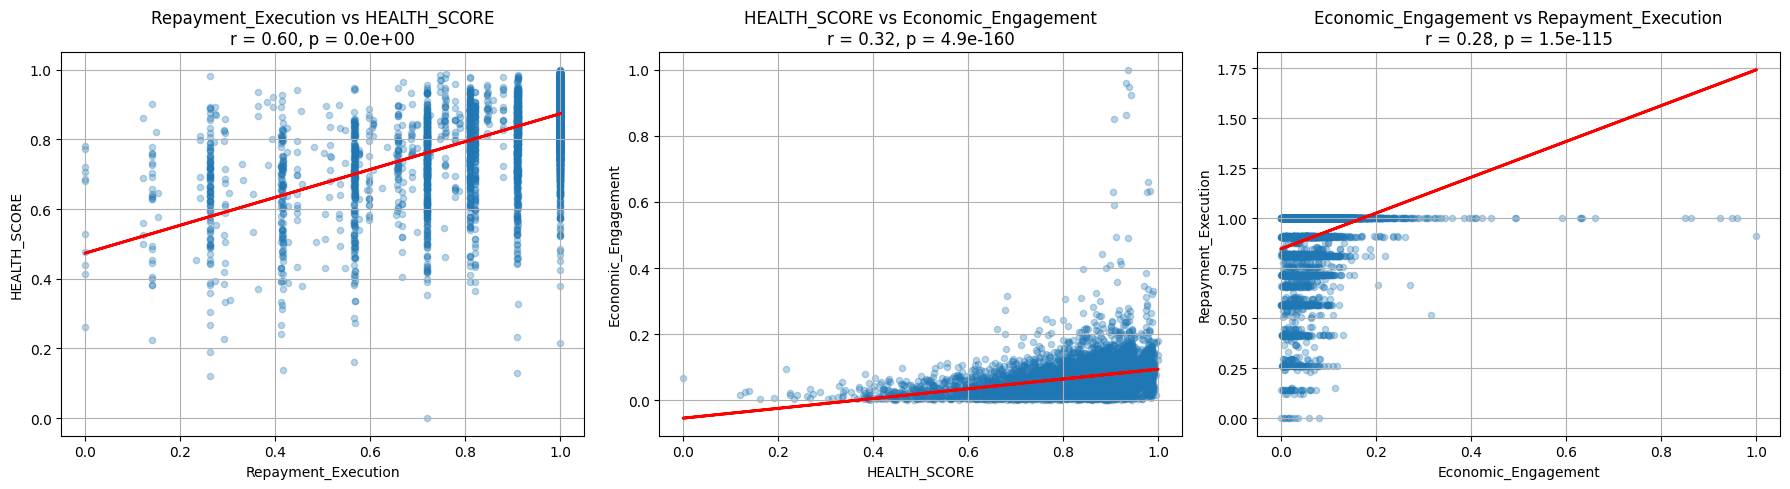

In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 0) 데이터 로드 & 병합
df_main   = pd.read_csv("./psid_with_target_prob.csv")
df_tenure = pd.read_csv("./psid_with_total_tenure.csv")
df = pd.merge(df_main,
              df_tenure[['ID','YEAR','total_tenure_years']],
              on=['ID','YEAR'], how='left')

# 1) 고령자(50세 이상)만 필터링
df = df[df["DEMO_AGE_GEN"] >= 50].copy()

# 2) HEALTH_SCORE 생성 ------------------------------------------------
df["HLTH_COST_RATIO"] = np.where(
    df["FINC_TOT_RDF"].abs()>0,
    df["EXPN_HLTH_TOT_RDF"]/(df["FINC_TOT_RDF"].abs()+1),
    np.nan
)
for src, dst in [
    ("CCON_ARTH_DEGR","Arthritis_deg_good"),
    ("CCON_ASTH_DEGR","Asthma_deg_good"),
    ("CCON_DIAB_DEGR","Diabetes_deg_good")
]:
    if src in df.columns:
        med, mx = df[src].median(), df[src].max()
        df[dst] = mx - df[src].fillna(med)

health_cols = [
    "GHLTH_STAT","DEP_SCORE_TOT","BMI",
    "HOSP_NUM","HLTH_COST_RATIO",
    "Arthritis_deg_good","Asthma_deg_good","Diabetes_deg_good"
]
H  = SimpleImputer(strategy="median").fit_transform(df[health_cols])
Hs = StandardScaler().fit_transform(H)
h_idx = PCA(n_components=1, random_state=42).fit_transform(Hs).ravel()
h_idx = (h_idx - h_idx.min())/(h_idx.max()-h_idx.min())
df["HEALTH_SCORE"] = h_idx  # 값↑일수록 건강↑

# 3) Economic_Engagement 생성 ----------------------------------------
econ_cols = [
    "FINC_TOT_RDF","WLTH_TOT_NET_RDF","WLTH_TOT_DEB_RDF",
    "total_tenure_years","TIME_WORK"
]
E  = SimpleImputer(strategy="median").fit_transform(df[econ_cols])
Es = StandardScaler().fit_transform(E)
e_idx = PCA(n_components=1, random_state=42).fit_transform(Es).ravel()
# 소득과 양의 상관 유지
if pearsonr(e_idx, df["FINC_TOT_RDF"].fillna(0))[0] < 0:
    e_idx *= -1
df["Economic_Engagement"] = (e_idx - e_idx.min())/(e_idx.max()-e_idx.min())

# 4) Repayment_Execution 생성 ----------------------------------------
# ADL/IADL '어려움 없음' 플래그
df["ADL_any_good"]  = 1 - df["ADL_SUM_ANY"].fillna(0)
df["IADL_any_good"] = 1 - df["IADL_SUM_ANY"].fillna(0)
# 세부 IADL 자립 여부
for i in range(1,7):
    src = f"IADL_Q{i}_ANY"
    dst = f"IADL_Q{i}_independent"
    if src in df.columns:
        df[dst] = (df[src].fillna(0)==0).astype(int)

rep_cols = ["ADL_any_good","IADL_any_good"] + \
           [c for c in df.columns if c.endswith("_independent")]
R  = SimpleImputer(strategy="median").fit_transform(df[rep_cols])
Rs = StandardScaler().fit_transform(R)
r_idx = PCA(n_components=1, random_state=42).fit_transform(Rs).ravel()
# ‘어려움 없음’과 양의 상관 유지
if pearsonr(r_idx, df["ADL_any_good"])[0] < 0:
    r_idx *= -1
df["Repayment_Execution"] = (r_idx - r_idx.min())/(r_idx.max()-r_idx.min())

# 5) 상관분석 & 산점도 시각화 ------------------------------------------
pairs = [
    ("Repayment_Execution","HEALTH_SCORE"),
    ("HEALTH_SCORE","Economic_Engagement"),
    ("Economic_Engagement","Repayment_Execution"),
]

fig, axes = plt.subplots(1,3, figsize=(18,5))
for ax,(x,y) in zip(axes,pairs):
    mask = df[[x,y]].notna().all(axis=1)
    xs, ys = df.loc[mask,x], df.loc[mask,y]
    r, p = pearsonr(xs, ys)
    ax.scatter(xs, ys, alpha=0.3, s=20)
    m, b = np.polyfit(xs, ys, 1)
    ax.plot(xs, m*xs + b, 'r-', lw=2)
    ax.set_title(f"{x} vs {y}\nr = {r:.2f}, p = {p:.1e}")
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.grid(True)

plt.tight_layout()
plt.show()


## 1.3 모델 제작 과정 프리뷰

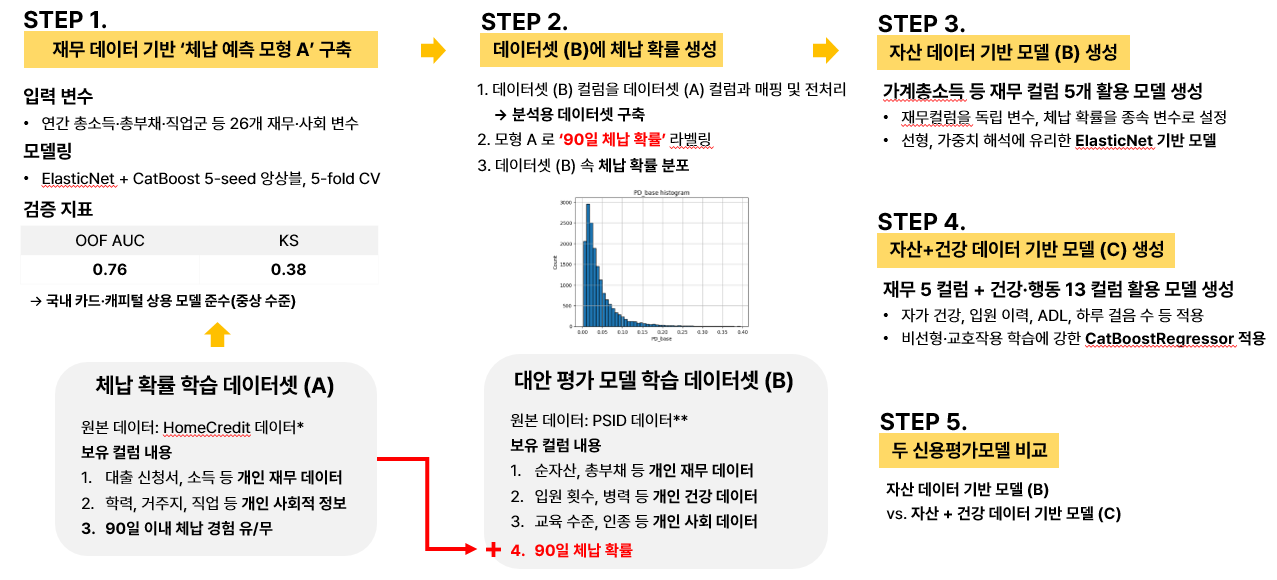

# 2. PSID 데이터 전처리

## 2.1 EDA

### 2.1.1 모델 제작에 필요한 컬럼 슬라이싱

In [ ]:
import numpy as np
import pandas as pd
import os
import dask.dataframe as dd
import gc # 가비지 컬렉션을 위한 모듈
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

# 1) 사용할 데이터 컬럼과 데이터 불러오기
cols = [
    # 통계적 변수
    'ID', 'YEAR', 'LINEAGE', 'PNUM', 'FUID', 'HHDID', 'RESPONDENT',
    'RESPONDENT_EXT', 'RINDIV', 'REL', 'REL_EXT', 'REFCOUPLE', 'SAMPLE',
    'SAMPSTAT', 'SAMPSTAT_EXT', 'SEQNUM', 'RESPONSE', 'RESPONSE_EXT',
    'PANEL_CURRENT', 'PANEL_INST', 'PANEL_MOVE', 'PANEL_DROP_STAT',
    'PANEL_DROP_REIN', 'PANEL_REIN_ELIG', 'FW', 'FW_CROSS',
    'IW', 'IW_CROSS', 'STRATUM', 'CLUSTER',

    # 인구통계학 변수
    'DEMO_SEX', 'DEMO_BIRTH_YEAR', 'DEMO_BIRTH_MONTH', 'DEMO_DEATH_REP',
    'DEMO_DEATH_YEAR', 'DEMO_AGE_GEN', 'DEMO_AGE_REP',

    # 만성질환
    'CCON_ARTH_DIAG_ANY', 'CCON_ARTH_DIAG_AGE', 'CCON_ARTH_DEGR',
    'CCON_ARTH_CARE', 'CCON_ASTH_DIAG_ANY', 'CCON_ASTH_DIAG_AGE',
    'CCON_ASTH_DEGR', 'CCON_ASTH_CARE', 'CCON_CANC_DIAG_ANY',
    'CCON_CANC_DIAG_AGE', 'CCON_CANC_DEGR', 
    'CCON_DIAB_DIAG_ANY', 'CCON_DIAB_DIAG_AGE', 'CCON_DIAB_DEGR',
    'CCON_DIAB_CARE',

    # covid관련
    'COVID_VACC', 'COVID_POSI', 'COVID_MEDI', 'COVID_TEST', 'COVID_DIAG',
    'COVID_SYMP', 'COVID_HOSP_ANY', 'COVID_HOSP_NUM', 'COVID_HOSP_TREAT_ICU',
    'COVID_HOSP_TREAT_OXY', 'COVID_HOSP_TREAT_VEN', 'COVID_HOSP_TREAT_OTH',
    'COVID_LING_ANY', 'COVID_LING_TYPE', 'COVID_LING_SEV',

    # 치매
    'DMNT_SCORE_TOT', 'DMNT_SCORE_CUT', 'DMNT_ELIG',

    # 우울증
    'DEP_SCORE_TOT', 'DEP_SCORE_CUT', 'DEP_DEGR',

    # 활동 가능 여부
    'ADL_SUM_TOT', 'ADL_SUM_ANY', 'IADL_SUM_TOT', 'IADL_SUM_ANY', #일상생활 능력 중 어느 하나라도 어려움이 있는지 여부

    # 집안일에 어려움 여부 / 그것이 건강 때문인지
    'IADL_Q1_ANY', # 식사 준비 능력 문제 여부
    'IADL_Q1_HEA', 
    'IADL_Q2_ANY', # 개인 물품 쇼핑 능력 문제 여부
    'IADL_Q2_HEA',
    'IADL_Q3_ANY', #돈 관리 능력 문제 여부
    'IADL_Q3_HEA', 'IADL_Q4_ANY', 'IADL_Q4_HEA',
    'IADL_Q5_ANY', 'IADL_Q5_HEA', 'IADL_Q6_ANY', 
    'IADL_Q6_HEA', # 건강 문제로 인한 가벼운 집안일 능력 문제 여부


    # 키와 몸무게 (체질량지수 구할 것)
    'BODY_HGHT_IN', 'BODY_HGHT_CM', 'BODY_WGHT_LB', 'BODY_WGHT_KG',

    # 삶의 만족도
    'LIFE_STAT',

    # 수입 (가족구성원 포함)
    'EARN_TOT_ND', 'EARN_TOT_NDF', 'EARN_TOT_RD', 'EARN_TOT_RDF',
    'EARN_TOT_ND_RP', 'EARN_TOT_ND_SP', 'EARN_TOT_NDF_RP',
    'EARN_TOT_NDF_SP', 'EARN_TOT_RD_RP', 'EARN_TOT_RD_SP',
    'EARN_TOT_RDF_RP', 'EARN_TOT_RDF_SP',

    # 고용(가족구성원 포함)
    'EMP_STAT_1M', 'EMP_STAT_2M', 'EMP_STAT_3M', 'EMP_STAT_1M_RP',
    'EMP_STAT_2M_RP', 'EMP_STAT_3M_RP', 'EMP_STAT_1M_SP',
    'EMP_STAT_2M_SP', 'EMP_STAT_3M_SP', 'EMP_WORK', 'EMP_WORK_RP',
    'EMP_WORK_SP', 'EMP_WORK_MM', 'EMP_WORK_MM_RP', 'EMP_WORK_MM_SP',

    # 지출 및 지출 항목( 주거 포함)
    'EXPN_TOT_ND', 'EXPN_TOT_NDF', 'EXPN_TOT_RD', 'EXPN_TOT_RDF',
    'EXPN_TOT_IRV_ND', 'EXPN_TOT_IRV_NDF', 'EXPN_TOT_IRV_RD',
    'EXPN_TOT_IRV_RDF', 'EXPN_CCAR_TOT_ND', 'EXPN_CCAR_TOT_NDF',
    'EXPN_CCAR_TOT_RD', 'EXPN_CCAR_TOT_RDF', 'EXPN_CLOT_TOT_ND',
    'EXPN_CLOT_TOT_NDF', 'EXPN_CLOT_TOT_RD', 'EXPN_CLOT_TOT_RDF',
    'EXPN_COMP_TOT_ND', 'EXPN_COMP_TOT_NDF', 'EXPN_COMP_TOT_RD',
    'EXPN_COMP_TOT_RDF', 'EXPN_EDUC_TOT_ND', 'EXPN_EDUC_TOT_NDF',
    'EXPN_EDUC_TOT_RD', 'EXPN_EDUC_TOT_RDF', 'EXPN_FOOD_TOT_ND',
    'EXPN_FOOD_TOT_NDF', 'EXPN_FOOD_TOT_RD', 'EXPN_FOOD_TOT_RDF',
    'EXPN_HOUS_TOT_ND', 'EXPN_HOUS_TOT_NDF', 'EXPN_HOUS_TOT_RD',
    'EXPN_HOUS_TOT_RDF', 'EXPN_OREC_TOT_ND', 'EXPN_OREC_TOT_NDF',
    'EXPN_OREC_TOT_RD', 'EXPN_OREC_TOT_RDF', 'EXPN_TRAN_TOT_ND',
    'EXPN_TRAN_TOT_NDF', 'EXPN_TRAN_TOT_RD', 'EXPN_TRAN_TOT_RDF',
    'EXPN_TRIP_TOT_ND', 'EXPN_TRIP_TOT_NDF', 'EXPN_TRIP_TOT_RD',
    'EXPN_TRIP_TOT_RDF',

    # 건강관련 비용
    'EXPN_HLTH_TOT_ND', 'EXPN_HLTH_TOT_NDF', 'EXPN_HLTH_TOT_RD',
    'EXPN_HLTH_TOT_RDF', 'EXPN_HLTH_DOC_ND', 'EXPN_HLTH_DOC_NDF',
    'EXPN_HLTH_DOC_RD', 'EXPN_HLTH_DOC_RDF', 'EXPN_HLTH_HOS_ND',
    'EXPN_HLTH_HOS_NDF', 'EXPN_HLTH_HOS_RD', 'EXPN_HLTH_HOS_RDF',
    'EXPN_HLTH_INS_ND', 'EXPN_HLTH_INS_NDF', 'EXPN_HLTH_INS_RD',
    'EXPN_HLTH_INS_RDF', 'EXPN_HLTH_PRE_ND', 'EXPN_HLTH_PRE_NDF',
    'EXPN_HLTH_PRE_RD', 'EXPN_HLTH_PRE_RDF',

    # 가구소득
    'FINC_TOT_ND', 'FINC_TOT_NDF', 'FINC_TOT_RD', 'FINC_TOT_RDF',

    # 직업
    'OCC_1970C', 'OCC_2000C_1M', 'OCC_2000C_2M', 'OCC_2000C_3M',
    'OCC_2000C_4M', 'OCC_2010C_1M', 'OCC_2010C_2M', 'OCC_2010C_3M',
    'OCC_2010C_4M',

    # 주택 소유/임대 상태
    'HOME_STAT',

    # 자산
    'WLTH_TOT_NET_ND', 'WLTH_TOT_NET_NDF', 'WLTH_TOT_NET_RD',
    'WLTH_TOT_NET_RDF', 'WLTH_TOT_NET_XH_ND', 'WLTH_TOT_NET_XH_NDF',
    'WLTH_TOT_NET_XH_RD', 'WLTH_TOT_NET_XH_RDF', 'WLTH_TOT_NET_XHR_ND',
    'WLTH_TOT_NET_XHR_NDF', 'WLTH_TOT_NET_XHR_RD', 'WLTH_TOT_NET_XHR_RDF',
    'WLTH_TOT_ASS_ND', 'WLTH_TOT_ASS_NDF', 'WLTH_TOT_ASS_RD',
    'WLTH_TOT_ASS_RDF', 'WLTH_TOT_ASS_XH_ND', 'WLTH_TOT_ASS_XH_NDF',
    'WLTH_TOT_ASS_XH_RD', 'WLTH_TOT_ASS_XH_RDF', 'WLTH_TOT_ASS_XHR_ND',
    'WLTH_TOT_ASS_XHR_NDF', 'WLTH_TOT_ASS_XHR_RD', 'WLTH_TOT_ASS_XHR_RDF',

    # 부채
    'WLTH_TOT_DEB_ND', 'WLTH_TOT_DEB_NDF', 'WLTH_TOT_DEB_RD',
    'WLTH_TOT_DEB_RDF', 'WLTH_TOT_DEB_XH_ND', 'WLTH_TOT_DEB_XH_NDF',
    'WLTH_TOT_DEB_XH_RD', 'WLTH_TOT_DEB_XH_RDF', 'WLTH_TOT_DEB_XHR_ND',
    'WLTH_TOT_DEB_XHR_NDF', 'WLTH_TOT_DEB_XHR_RD', 'WLTH_TOT_DEB_XHR_RDF',

    # 자산구성요소
    'WLTH_HOME_NET_ND', 'WLTH_HOME_NET_NDF', 'WLTH_HOME_NET_RD',
    'WLTH_HOME_NET_RDF', 'WLTH_HOME_ASS_ND', 'WLTH_HOME_ASS_NDF',
    'WLTH_HOME_ASS_RD', 'WLTH_HOME_ASS_RDF', 'WLTH_HOME_DEB_ND',
    'WLTH_HOME_DEB_NDF', 'WLTH_HOME_DEB_RD', 'WLTH_HOME_DEB_RDF',
    'WLTH_REAL_NET_ND', 'WLTH_REAL_NET_NDF', 'WLTH_REAL_NET_RD',
    'WLTH_REAL_NET_RDF', 'WLTH_REAL_ASS_ND', 'WLTH_REAL_ASS_NDF',
    'WLTH_REAL_ASS_RD', 'WLTH_REAL_ASS_RDF', 'WLTH_REAL_DEB_ND',
    'WLTH_REAL_DEB_NDF', 'WLTH_REAL_DEB_RD', 'WLTH_REAL_DEB_RDF',
    'WLTH_FBUS_NET_ND', 'WLTH_FBUS_NET_NDF', 'WLTH_FBUS_NET_RD',
    'WLTH_FBUS_NET_RDF', 'WLTH_FBUS_ASS_ND', 'WLTH_FBUS_ASS_NDF',
    'WLTH_FBUS_ASS_RD', 'WLTH_FBUS_ASS_RDF', 'WLTH_FBUS_DEB_ND',
    'WLTH_FBUS_DEB_NDF', 'WLTH_FBUS_DEB_RD', 'WLTH_FBUS_DEB_RDF',
    'WLTH_SAVI_NET_ND', 'WLTH_SAVI_NET_NDF', 'WLTH_SAVI_NET_RD',
    'WLTH_SAVI_NET_RDF', 'WLTH_SAVI_BNK_ND', 'WLTH_SAVI_BNK_NDF',
    'WLTH_SAVI_BNK_RD', 'WLTH_SAVI_BNK_RDF', 'WLTH_SAVI_BND_ND',
    'WLTH_SAVI_BND_NDF', 'WLTH_SAVI_BND_RD', 'WLTH_SAVI_BND_RDF',
    'WLTH_INVE_NET_ND', 'WLTH_INVE_NET_NDF', 'WLTH_INVE_NET_RD',
    'WLTH_INVE_NET_RDF', 'WLTH_INVE_IRA_ND', 'WLTH_INVE_IRA_NDF',
    'WLTH_INVE_IRA_RD', 'WLTH_INVE_IRA_RDF', 'WLTH_INVE_STK_ND',
    'WLTH_INVE_STK_NDF', 'WLTH_INVE_STK_RD', 'WLTH_INVE_STK_RDF',
    'WLTH_VEHI_NET_ND', 'WLTH_VEHI_NET_NDF', 'WLTH_VEHI_NET_RD',
    'WLTH_VEHI_NET_RDF', 'WLTH_OASS_NET_ND', 'WLTH_OASS_NET_NDF',
    'WLTH_OASS_NET_RD', 'WLTH_OASS_NET_RDF',

    # 신용카드 부채 잔액
    'WLTH_ODEB_NET_ND', 'WLTH_ODEB_NET_NDF', 'WLTH_ODEB_NET_RD',
    'WLTH_ODEB_NET_RDF', 'WLTH_ODEB_CRE_ND', 'WLTH_ODEB_CRE_NDF',
    'WLTH_ODEB_CRE_RD', 'WLTH_ODEB_CRE_RDF', 'WLTH_ODEB_FAM_ND',
    'WLTH_ODEB_FAM_NDF', 'WLTH_ODEB_FAM_RD', 'WLTH_ODEB_FAM_RDF',
    'WLTH_ODEB_LEG_ND', 'WLTH_ODEB_LEG_NDF', 'WLTH_ODEB_LEG_RD',
    'WLTH_ODEB_LEG_RDF', 'WLTH_ODEB_MED_ND', 'WLTH_ODEB_MED_NDF',
    'WLTH_ODEB_MED_RD', 'WLTH_ODEB_MED_RDF', 'WLTH_ODEB_STU_ND',
    'WLTH_ODEB_STU_NDF', 'WLTH_ODEB_STU_RD', 'WLTH_ODEB_STU_RDF',
    'WLTH_ODEB_REM_ND', 'WLTH_ODEB_REM_NDF', 'WLTH_ODEB_REM_RD',
    'WLTH_ODEB_REM_RDF',

    # 시간사용 행태
    'TIME_ACAR', 'TIME_CCAR', 'TIME_EDUC', 'TIME_HOUS', 'TIME_LEIS',
    'TIME_PERS', 'TIME_SHOP', 'TIME_VOLU', 'TIME_WORK',
   
    'GHLTH_STAT', # 전반적인 건강 상태
    'GHLTH_CHNG', # 건강 변화
    'HOSP_ANY', # 병원 입원 경험
    'HOSP_NUM',# 병원 입원 횟수
]

### 2.1.2 결측치, 이상치 처리

In [ ]:
input_dir = 'export'

print(f"'{input_dir}' 디렉토리에서 Parquet 청크 파일들을 Dask DataFrame으로 불러오는 중...")

try:
    # Dask는 디렉토리 경로만 지정하면 그 안에 있는 모든 Parquet 파일을 자동으로 읽습니다.
    # read_parquet는 wildcards (예: *.parquet)도 지원합니다.
    ddf = dd.read_parquet(os.path.join(input_dir, '*.parquet'))

    print("Dask DataFrame이 성공적으로 생성되었습니다 (지연 로드).")
    print(f"Dask DataFrame의 예상 행 수: {len(ddf)}") # 실제 계산이 아니므로 빠름
    print(f"Dask DataFrame의 예상 컬럼 수: {len(ddf.columns)}")
    print("\nDask DataFrame 정보 (스키마):")
    print(ddf.info())
    print("\nDask DataFrame 상위 5개 행 (실제 데이터 로드 시작):")
    # .head()를 호출하면 Dask가 첫 몇 행을 계산하기 위해 데이터를 메모리에 로드합니다.
    print(ddf.head())

except Exception as e:
    print(f"Dask DataFrame을 불러오는 중 예상치 못한 오류가 발생했습니다: {e}")
    print("Dask 설치 또는 파일 경로를 확인해 주세요.")

##### 1) 19년도 20년도 파일만 추출
ddf_2019_2021 = ddf[ddf['YEAR'].isin([2019, 2021])]

##### 2) '0'대치 컬럼 적용

# 'CCON_' 접두사를 가진 컬럼들 찾기
ccon_columns = [col for col in ddf_2019_2021.columns if col.startswith('CCON_')]

if ccon_columns:
    print(f"찾은 'ccon_' 접두사 컬럼: {ccon_columns}")
    
    # 해당 컬럼들의 NaN 값을 0으로 대체
    ddf_2019_2021[ccon_columns] = ddf_2019_2021[ccon_columns].fillna(0)
    
    print("\n--- NaN이 0으로 대체된 DataFrame (ccon_ 접두사 컬럼) ---")
    print(ddf_2019_2021[ccon_columns])
else:
    print("DataFrame에서 'ccon_' 접두사를 가진 컬럼을 찾을 수 없습니다.")

# ''IADL_Q' 접두사를 가진 컬럼들 찾기
iadl_columns = [col for col in ddf_2019_2021.columns if col.startswith('IADL_Q')]

if iadl_columns:
    print(f"찾은 'IADL_Q' 접두사 컬럼: {iadl_columns}")
    
    # 해당 컬럼들의 NaN 값을 0으로 대체
    ddf_2019_2021[iadl_columns] = ddf_2019_2021[iadl_columns].fillna(0)
    
    print("\n--- NaN이 0으로 대체된 DataFrame (IADL_Q 접두사 컬럼) ---")
    print(ddf_2019_2021[iadl_columns])
else:
    print("DataFrame에서 'IADL_Q' 접두사를 가진 컬럼을 찾을 수 없습니다.")
# ''OCC_' 접두사를 가진 컬럼들 찾기
occ_columns = [col for col in ddf_cleaned.columns if col.startswith('OCC_')]

if occ_columns:
    print(f"찾은 'OCC_' 접두사 컬럼: {occ_columns}")
    
    # 해당 컬럼들의 NaN 값을 0으로 대체
    ddf_cleaned[occ_columns] = ddf_cleaned[occ_columns].fillna(0)
    
    print("\n--- NaN이 0으로 대체된 DataFrame (OCC_ 접두사 컬럼) ---")
    print(ddf_cleaned[occ_columns])
else:
    print("DataFrame에서 'OCC_' 접두사를 가진 컬럼을 찾을 수 없습니다.")
    
# ''EMP_STAT' 접두사를 가진 컬럼들 찾기
emp_columns = [col for col in ddf_cleaned.columns if col.startswith('EMP_STAT')]

if emp_columns:
    print(f"찾은 'IADL_Q' 접두사 컬럼: {iadl_columns}")
    
    # 해당 컬럼들의 NaN 값을 0으로 대체
    ddf_cleaned[emp_columns] = ddf_cleaned[emp_columns].fillna(0)
    
    print("\n--- NaN이 0으로 대체된 DataFrame (EMP_STAT 접두사 컬럼) ---")
    print(ddf_cleaned[emp_columns])
else:
    print("DataFrame에서 'EMP_STAT' 접두사를 가진 컬럼을 찾을 수 없습니다.")
    
# ''HOSP_' 접두사를 가진 컬럼들 찾기
hosp_columns = [col for col in ddf_cleaned.columns if col.startswith('HOSP_')]

if hosp_columns:
    print(f"찾은 'HOSP_' 접두사 컬럼: {hosp_columns}")
    
    # 해당 컬럼들의 NaN 값을 0으로 대체
    ddf_cleaned[hosp_columns] = ddf_cleaned[hosp_columns].fillna(0)
    
    print("\n--- NaN이 0으로 대체된 DataFrame (HOSP_ 접두사 컬럼) ---")
    print(ddf_cleaned[hosp_columns])
else:
    print("DataFrame에서 'HOSP_' 접두사를 가진 컬럼을 찾을 수 없습니다.")
    
# ''DEP_' 접두사를 가진 컬럼들 찾기
dep_columns = [col for col in ddf_cleaned.columns if col.startswith('DEP_')]

if dep_columns:
    print(f"찾은 'DEP_' 접두사 컬럼: {dep_columns}")
    
    # 해당 컬럼들의 NaN 값을 0으로 대체
    ddf_cleaned[dep_columns] = ddf_cleaned[dep_columns].fillna(0)
    
    print("\n--- NaN이 0으로 대체된 DataFrame (DEP_ 접두사 컬럼) ---")
    print(ddf_cleaned[dep_columns])
else:
    print("DataFrame에서 'DEP_' 접두사를 가진 컬럼을 찾을 수 없습니다.")


# ''DMNT_' 접두사를 가진 컬럼들 찾기
dmnt_columns = [col for col in ddf_cleaned.columns if col.startswith('DMNT_')]

if dep_columns:
    print(f"찾은 'DMNT_' 접두사 컬럼: {dmnt_columns}")
    
    # 해당 컬럼들의 NaN 값을 0으로 대체
    ddf_cleaned[dmnt_columns] = ddf_cleaned[dmnt_columns].fillna(0)
    
    print("\n--- NaN이 0으로 대체된 DataFrame (DMNT_접두사 컬럼) ---")
    print(ddf_cleaned[dmnt_columns])
else:
    print("DataFrame에서 'DMNT_' 접두사를 가진 컬럼을 찾을 수 없습니다.")
    
# '0' 만들 컬럼
c_columns = ['EMP_WORK_SP','EMP_WORK_MM_SP','ADL_SUM_TOT','ADL_SUM_ANY', 'IADL_SUM_TOT','IADL_SUM_ANY' ]

if c_columns:
    print(f"찾은  컬럼: {c_columns}")
    
    # 해당 컬럼들의 NaN 값을 0으로 대체
    adult[c_columns] = adult[c_columns].fillna(0)
    
    print("\n--- NaN이 0으로 대체된 DataFrame ---")
    print(adult[c_columns])
else:
    print("DataFrame에서 해당 컬럼을 찾을 수 없습니다.")

    
##### 2) 미성년자 삭제
minor_ids_to_remove = works[works['DEMO_AGE_REP'] < 18]['ID'].unique()
adult = works[~works['ID'].isin(minor_ids_to_remove)].copy()

##### 4) BMI 값 생성 후 키와 몸무게 컬럼 삭제 
adult['BMI'] = adult['BODY_WGHT_KG'] / ((adult['BODY_HGHT_CM'] / 100) * (adult['BODY_HGHT_CM'] / 100))
adult.drop(['BODY_WGHT_LB', 'BODY_HGHT_IN', 'BODY_HGHT_CM','BODY_WGHT_KG'], axis =1)

##### 5) 결측치가 너무 많아서 쓰지 않기로 결정한 컬럼명 삭제

# 삭제할 컬럼
d_columns = ['TIME_ACAR', 'TIME_VOLU', 
            'TIME_ACAR',   # 자동차 관련 활동
             'TIME_VOLU',   # 봉사활동
             'TIME_CCAR',   # 대중교통/자가용 이동
             'TIME_EDUC',   # 교육 활동
             'TIME_HOUS',   # 가사 활동
             'TIME_SHOP',   # 쇼핑 활동
             'TIME_LEIS',   # 여가 활동
             'TIME_PERS',   # 개인 관리
             'TIME_WORK',    # 근로 활동
            ]

if c_columns:
    print(f"찾은  컬럼: {c_columns}")
    
    # 해당 컬럼들 삭제
    adult = adult.drop(columns =c_columns)
    
    print("\n--- NaN이 0으로 대체된 DataFrame ---")
    print(adult[c_columns])
else:
    print("DataFrame에서 해당 컬럼을 찾을 수 없습니다.")
    
##### 6) 중간 결과 저장
# CSV 파일을 저장할 디렉토리 경로
output_csv_dir = 'filtered_2019_2021_data_csv'

# 디렉토리가 없으면 생성
os.makedirs(output_csv_dir, exist_ok=True)

print(f"'{output_csv_dir}' 디렉토리에 Dask DataFrame을 CSV 파일로 추출 중...")
try:
    adult.to_csv('filled_data.csv', index=False)

    print(f" DataFrame이 '{output_csv_dir}' 디렉토리에 성공적으로 CSV 파일로 추출되었습니다.")
    print("생성된 CSV 파일(들)을 확인하세요. (예: part_00000.csv, part_00001.csv 등)")

except Exception as e:
    print(f"CSV 추출 중 오류가 발생했습니다: {e}")
    print("출력 디렉토리 권한, 디스크 공간, 또는 Dask DataFrame 상태를 확인해 주세요.")
    
##### 7) 응답자인 경우만 저장
filled_3 = filled[filled['RINDIV'] == 1].copy()
print("--- 초기 'target' DataFrame (RINDIV == 1인 행) ---")
print(len(filled_3)
all_rindiv_is_one_per_id = filled.groupby('ID')['RINDIV'].transform(lambda x: (x == 1).all())
filled_3 = filled_3[filled_3['ID'].isin(filled[all_rindiv_is_one_per_id]['ID'].unique())]

print("--- 최종 'target' DataFrame (ID 그룹 내 RINDIV가 모두 1인 경우만 포함) ---")
print(len(filled_3))

##### 8) 최종 결측치 확인

print("\n[단계 1/2]: 각 컬럼별 결측치 개수 계산 중...")
missing_counts = filled.isna().sum()
total_rows = len(filled)

print("[단계 2/2]: 각 컬럼별 결측치 비율 계산 중...")
missing_percentages = (missing_counts / total_rows) * 100 

print("\n==================== 컬럼별 결측치 현황 ====================\n")

missing_info_df = missing_counts.to_frame(name='Missing Count')
missing_info_df['Missing Percentage (%)'] = missing_percentages
missing_info_df = missing_info_df.sort_values(by='Missing Count', ascending=False)
print(missing_info_df)
print("\n===========================================================\n")

print(f"전체 DataFrame의 총 결측치 개수: {missing_counts.sum()}")

## 2.2 모델 제작에 필요한 컬럼 추가 슬라이싱
-  "ID", "YEAR", "FAM_SIZE", "FAM_MARSTAT", "FAM_SIZE_CHI", "EDU_LEVEL", "GEO_REGION"

#### ID만 생성

In [1]:
import pandas as pd

data = pd.read_csv('./7_filled_data3.csv')
ids = data['ID']
ids.to_csv('./id_data.csv')

#### filled_data에 없는 컬럼만 새로 추출

In [2]:
import pandas as pd

# ── 1. ID 목록 읽기 ──────────────────────────────
ids = (
    pd.read_csv("./id_data.csv")        # 업로드한 ID 목록
      ["ID"].dropna().astype(int).unique()
)
ids_set = set(ids)

# ── 2. PSID-SHELF 원본에서 필요한 열만 슬라이스 ─
KEEP_COLS = [
    "ID", "YEAR",
    "FAM_SIZE", "FAM_MARSTAT", "FAM_SIZE_CHI",
    "EDU_LEVEL", "GEO_REGION"
]

df = pd.read_csv("./PSIDSHELF_1968_2021_LONG.csv", usecols=KEEP_COLS)

# ── 3. ID·연도 필터 후 저장 ─────────────────────
out = df[df["ID"].isin(ids_set) & df["YEAR"].isin([2019, 2021])]

out.to_csv("./id_slice_2019_2021.csv", index=False)
print("✅ 저장 완료 → id_slice_2019_2021.csv")

✅ 저장 완료 → id_slice_2019_2021.csv


#### filled_data와 병합

In [3]:
import pandas as pd

# ── 경로 정의 ───────────────────────────
FILLED_PATH = "./7_filled_data3.csv"           # 기존 HC 매핑 파일
SLICE_PATH  = "./id_slice_2019_2021.csv"    # 2019·2021 추가 컬럼만 추출한 파일
OUTPUT_PATH = "./filled_merged.csv"

# ── 1. 파일 로드 ───────────────────────
filled_df = pd.read_csv(FILLED_PATH)
slice_df  = pd.read_csv(SLICE_PATH)

# ── 2. ID·YEAR 기준 병합 ────────────────
merged = filled_df.merge(
    slice_df,
    on=["ID", "YEAR"],
    how="left",           # slice_df 컬럼을 붙이고 값 없으면 NaN
    validate="1:1"        # ID·YEAR 당 최대 1행씩만 존재해야 함
)

# ── 3. 결과 저장 ───────────────────────
merged.to_csv(OUTPUT_PATH, index=False)
print(f"✅ 병합 완료 → '{OUTPUT_PATH}'  (Rows: {len(merged):,}, Cols: {len(merged.columns)})")


✅ 병합 완료 → './filled_merged.csv'  (Rows: 16,476, Cols: 337)


#### 병합한 데이터 값에서 결측지 제거

In [4]:
import pandas as pd

# ── 경로 설정 ───────────────────────────────
INPUT_PATH  = "filled_merged.csv"          # 병합된 파일
OUTPUT_PATH = "filled_merged_clean.csv"    # 결측 제거 후 저장 파일

# ── 1. 데이터 로드 ─────────────────────────
df = pd.read_csv(INPUT_PATH)

# ── 2. 결측 행 삭제 ───────────────────────
cols_to_check = ["FAM_SIZE", "FAM_MARSTAT",
                 "FAM_SIZE_CHI", "EDU_LEVEL", "GEO_REGION"]

clean_df = df.dropna(subset=cols_to_check).reset_index(drop=True)

print(f"삭제 전: {len(df):,} rows → 삭제 후: {len(clean_df):,} rows")

# ── 3. 저장 ────────────────────────────────
clean_df.to_csv(OUTPUT_PATH, index=False)
print(f"✅ 완료 → '{OUTPUT_PATH}'")

삭제 전: 16,476 rows → 삭제 후: 16,455 rows
✅ 완료 → 'filled_merged_clean.csv'


#### 결측치 없는 데이터셋에서 필요한 컬럼만 추출해 새로 csv 파일생성 

In [19]:
import pandas as pd, csv

SRC  = "./filled_merged_clean.csv"          # PSID 원본
OUT  = "./psid_core_cols.csv"       # 슬라이스 결과

# ── 1. 모델·파생에 필요한 PSID 원천 컬럼 목록 ──────────────
core_cols = [
    # ─ PK ──────────────────────────────────────────────
    "ID", "YEAR",

    # ─ 기본 인구·고용 ─────────────────────────────────
    "DEMO_SEX",          # CODE_GENDER
    "DEMO_AGE_GEN",      # DAYS_BIRTH
    "EMP_WORK_MM_RP",    # 최근 12개월 근무월수 (EMP_DUR_YEARS 보조)

    # ─ 가족·교육·지역 ────────────────────────────────
    "FAM_SIZE_CHI", "FAM_SIZE",
    "FAM_MARSTAT",       # NAME_FAMILY_STATUS
    "EDU_LEVEL",         # NAME_EDUCATION_TYPE
    "GEO_REGION",

    # ─ 직업·고용상태 ─────────────────────────────────
    "EMP_STAT_1M", "EMP_STAT_2M", "EMP_STAT_3M",
    "OCC_2010C_1M",

    # ─ 주거·차량 보유 ────────────────────────────────
    "HOME_STAT",         # FLAG_OWN_REALTY
    "WLTH_VEHI_NET_ND",  # FLAG_OWN_CAR

    # ─ 소득 ─────────────────────────────────────────
    "FINC_TOT_ND",       # 가구 총소득
    "EARN_TOT_ND",       # 개인 비반올림
    "EARN_TOT_RD",       # 개인 반올림
    "EARN_TOT_ND_RP",    # 응답자 개인소득

    # ─ 자산 · 부채 ───────────────────────────────────
    "WLTH_TOT_ASS_RD",   # 총 자산
    "WLTH_TOT_DEB_RD",   # 총 부채(반올림) → BUR_DEBT_RATIO
    "WLTH_TOT_DEB_ND",   # 총 부채(비반올림) → BUR_DEBT_SUM
    "WLTH_HOME_ASS_ND",  # 주택 가치 → MOR_CR_SUM
    "WLTH_HOME_DEB_ND",  # 모기지 잔액 → MOR_DEBT_SUM
    "WLTH_ODEB_CRE_ND",  # 신용카드 부채 (있으면)
    "WLTH_ODEB_NET_ND",  # 기타 부채
    # 여기까지 있으면 BUR_CR_SUM 산식을 위한 자산 분해도 가능

    # ─ 지출 ──────────────────────────────────────────
    "EXPN_HOUS_TOT_ND",  # 주거 총지출 → AMT_ANNUITY proxy
    "EXPN_TOT_ND",       # 총 지출 (보조)

    # ─ 기타(추후 외부 조인 자리) ─────────────────────
    # "EXT_PROXY_1", "EXT_PROXY_2", "EXT_PROXY_3"
]


# ── 2. 원본 헤더에서 실제 존재 컬럼만 선택 ────────────────
cols0   = pd.read_csv(SRC, nrows=0).columns
exists  = [c for c in core_cols if c in cols0]
missing = list(set(core_cols) - set(exists))
print("✔ 존재:", len(exists), "| ✖ 없는:", missing)

# ── 3. 헤더 먼저 저장 (없던 컬럼은 NaN 채울 준비) ────────
with open(OUT, "w", newline="") as f:
    csv.writer(f).writerow(core_cols)

# ── 4. 100k 행씩 스트리밍 → 슬라이스 저장 ──────────────
for chunk in pd.read_csv(SRC, usecols=exists, chunksize=100_000, low_memory=False):
    # 빠진 컬럼은 NaN 으로 추가
    for m in missing:
        chunk[m] = pd.NA
    # 컬럼 순서 맞춰서 이어붙이기
    chunk = chunk[core_cols]
    chunk.to_csv(OUT, mode="a", header=False, index=False)

print(f"✅ 슬라이스 완료 → {OUT}")


✔ 존재: 29 | ✖ 없는: []
✅ 슬라이스 완료 → ./psid_core_cols.csv


# 3. 체납 예측 모델 제작

## 3.1 HC 기반 예측 확률 모델

### 3.1.1 모델 제작 과정

In [65]:
# ── 0. PATH & LIB ──────────────────────────────────────────
APP, BUREAU, CCBAL, INST = (
    "./home-credit-default-risk/application_train.csv",
    "./home-credit-default-risk/bureau.csv",
    "./home-credit-default-risk/credit_card_balance.csv",
    "./home-credit-default-risk/installments_payments.csv",
)

import pandas as pd, numpy as np, joblib, warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from catboost import CatBoostClassifier
warnings.filterwarnings("ignore")

# ── 1. FEATURE ENGINEERING ─────────────────────────────────
def build_features():
    # 1‑1 application ----------------------------------------------------------
    base_cols = [
        "SK_ID_CURR","TARGET",
        # ─ categorical ─
        "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
        "NAME_INCOME_TYPE","OCCUPATION_TYPE",
        "FLAG_OWN_REALTY","FLAG_OWN_CAR",
        # ─ numeric ─
        "DAYS_BIRTH","DAYS_EMPLOYED",
        "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
        "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY",
        "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"
    ]
    app = pd.read_csv(APP, usecols=lambda c: c in base_cols)

    # 1‑2 bureau ---------------------------------------------------------------
    bur = pd.read_csv(
        BUREAU,
        usecols=["SK_ID_CURR","CREDIT_ACTIVE","AMT_CREDIT_SUM","AMT_CREDIT_SUM_DEBT"]
    )
    active = bur[bur.CREDIT_ACTIVE=="Active"]
    agg_all = active.groupby("SK_ID_CURR").agg(
        BUR_CR_SUM=("AMT_CREDIT_SUM","sum"),
        BUR_DEBT_SUM=("AMT_CREDIT_SUM_DEBT","sum")
    )
    agg_all["BUR_DEBT_RATIO"] = (agg_all.BUR_DEBT_SUM/agg_all.BUR_CR_SUM)\
                                .replace([np.inf,-np.inf], np.nan)

    # 1‑3 credit card ----------------------------------------------------------
    cc = pd.read_csv(
        CCBAL, usecols=["SK_ID_CURR","AMT_BALANCE"]
    )
    cc_agg = cc.groupby("SK_ID_CURR").agg(
        CC_BALANCE_SUM=("AMT_BALANCE","sum")
    )

    # 1‑4 installments (12 months) --------------------------------------------
    inst = pd.read_csv(
        INST,
        usecols=["SK_ID_CURR","AMT_INSTALMENT","DAYS_INSTALMENT"]
    )
    inst = inst[inst.DAYS_INSTALMENT > -365]
    inst_agg = inst.groupby("SK_ID_CURR").agg(
        INST_AMT_DUE=("AMT_INSTALMENT","sum")
    )

    # 1‑5 merge ---------------------------------------------------------------
    df = app.merge(agg_all, on="SK_ID_CURR", how="left")\
            .merge(cc_agg,  on="SK_ID_CURR", how="left")\
            .merge(inst_agg,on="SK_ID_CURR", how="left")

    # 1‑6 파생 -----------------------------------------------------------------
    df["AGE_YEARS"]  = (-df.DAYS_BIRTH/365).round(1)
    df["EMP_YEARS"]  = (-df.DAYS_EMPLOYED/365).clip(0,70)
    df["CREDIT_INCOME_RATIO"]  = df.AMT_CREDIT  / df.AMT_INCOME_TOTAL
    df["ANNUITY_INCOME_RATIO"] = df.AMT_ANNUITY / df.AMT_INCOME_TOTAL
    df["ANNUITY_CREDIT_RATIO"] = df.AMT_ANNUITY / df.AMT_CREDIT
    # df["INCOME_PER_FAM"]       = df.AMT_INCOME_TOTAL/(df.CNT_FAM_MEMBERS+1)
    # df["CHILD_RATIO"]          = df.CNT_CHILDREN/(df.CNT_FAM_MEMBERS+1)

    # 1‑7 최종 피처 리스트 ------------------------------------------------------
    num_cols = [
        # 기본 수치
        "AGE_YEARS","EMP_YEARS",
        "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE",
        "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY",
        "EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3",
        # bureau / card / inst
        "BUR_DEBT_SUM","BUR_DEBT_RATIO",
        # ratio
        "CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO","ANNUITY_CREDIT_RATIO",
        "INCOME_PER_FAM"
    ]

    cat_cols = [
        "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
        "NAME_INCOME_TYPE","OCCUPATION_TYPE",
        "FLAG_OWN_REALTY","FLAG_OWN_CAR"
    ]

    # 존재 여부 대비
    num_cols = [c for c in num_cols if c in df.columns]
    cat_cols = [c for c in cat_cols if c in df.columns]

    X = df[num_cols + cat_cols].copy()
    y = df["TARGET"].copy()

    X[num_cols] = X[num_cols].fillna(-999).astype("float32")
    for c in cat_cols:
        X[c] = X[c].fillna("Missing").astype("category")

    return X, y, cat_cols

# ── 2. TRAINING (CatBoost GPU, 3‑seed) ─────────────────────
def run_cv(seed):
    X, y, cat_cols = build_features()
    skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    oof   = np.zeros(len(X))
    scale = (y == 0).sum() / (y == 1).sum()

    params = dict(
        task_type="GPU", devices="0",
        iterations=1500, learning_rate=0.02, depth=10,
        bootstrap_type="Bernoulli",   # ★ GPU + subsample 허용
        subsample=0.8,
        l2_leaf_reg=4,
        loss_function="Logloss", eval_metric="AUC",
        class_weights=[1, scale],
        random_seed=seed, early_stopping_rounds=200,
        verbose=250
    )

    for fold, (tr, va) in enumerate(skf.split(X, y), 1):
        model = CatBoostClassifier(**params)
        model.fit(
            X.iloc[tr], y.iloc[tr],
            cat_features=cat_cols,
            eval_set=(X.iloc[va], y.iloc[va])
        )
        oof[va] = model.predict_proba(X.iloc[va])[:, 1]
        joblib.dump(model, f"hc_cb_fold{fold}_seed{seed}.pkl")

        prauc = average_precision_score(y.iloc[va], oof[va])
        print(f"[seed {seed} | fold {fold}] PRAUC = {prauc:.4f}")

    return oof

def ks_statistic(y_true, y_prob):
    """
    Kolmogorov–Smirnov statistic for binary classification.
    KS = max|CDF_Pos - CDF_Neg|
    """
    fpr, tpr, _ = roc_curve(y_true, y_prob)        # fpr=1‑Spec, tpr=Recall
    ks = np.max(np.abs(tpr - fpr))                 # 최대 거리를 KS 로 정의
    return ks

def print_metrics(y_true, y_prob, label="OOF"):
    pra  = average_precision_score(y_true, y_prob)
    auc  = roc_auc_score(y_true, y_prob)
    ks   = ks_statistic(y_true, y_prob)
    bri  = brier_score_loss(y_true, y_prob)

    print(f"\n📊  {label} Metrics")
    print(f"  • PRAUC       : {pra: .4f}")
    print(f"  • ROC‑AUC     : {auc: .4f}")
    print(f"  • KS‑Statistic: {ks : .4f}")
    print(f"  • Brier Score : {bri: .4f}")


# ── 3. MAIN ────────────────────────────────────────────────
if __name__ == "__main__":
    # 3‑seed 앙상블
    oof_final = np.zeros(pd.read_csv(APP, usecols=["SK_ID_CURR"]).shape[0])
    for s in (42,52,62,72,82):
        oof_final += run_cv(s) / 5.0

    y_full = pd.read_csv(APP, usecols=["TARGET"])["TARGET"]
    final_prauc = average_precision_score(y_full, oof_final)

    np.save("oof_preds.npy", oof_final)
    print(f"\n★ 최종 OOF PRAUC = {final_prauc:.4f}")
    print("✅ 모델 & OOF 저장 완료")
    

    # ▼ 기존 PRAUC 외에 추가 지표 출력
    print_metrics(y_full, oof_final, label="OOF Ensemble")

    np.save("oof_preds.npy", oof_final)
    print("✅ 모든 지표 계산 및 저장 완료")
    

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7102216	best: 0.7102216 (0)	total: 263ms	remaining: 6m 33s
250:	test: 0.7519866	best: 0.7520159 (249)	total: 1m 5s	remaining: 5m 28s
500:	test: 0.7553913	best: 0.7554368 (498)	total: 2m 12s	remaining: 4m 25s
bestTest = 0.7554368079
bestIteration = 498
Shrink model to first 499 iterations.
[seed 42 | fold 1] PRAUC = 0.2409


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7188243	best: 0.7188243 (0)	total: 341ms	remaining: 8m 30s
250:	test: 0.7606286	best: 0.7606702 (246)	total: 1m 13s	remaining: 6m 4s
500:	test: 0.7633169	best: 0.7633169 (500)	total: 2m 27s	remaining: 4m 54s
750:	test: 0.7637392	best: 0.7641855 (612)	total: 3m 57s	remaining: 3m 57s
bestTest = 0.764185518
bestIteration = 612
Shrink model to first 613 iterations.
[seed 42 | fold 2] PRAUC = 0.2511


Default metric period is 5 because AUC is/are not implemented for GPU


...

0:	test: 0.7012765	best: 0.7012765 (0)	total: 352ms	remaining: 8m 47s
250:	test: 0.7526864	best: 0.7526864 (250)	total: 1m 17s	remaining: 6m 23s
500:	test: 0.7559875	best: 0.7560062 (499)	total: 2m 32s	remaining: 5m 4s
750:	test: 0.7570336	best: 0.7572713 (691)	total: 3m 48s	remaining: 3m 47s
bestTest = 0.7572712898
bestIteration = 691
Shrink model to first 692 iterations.
[seed 82 | fold 3] PRAUC = 0.2517


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7130694	best: 0.7130694 (0)	total: 397ms	remaining: 9m 54s
250:	test: 0.7557286	best: 0.7557286 (250)	total: 1m 14s	remaining: 6m 11s
500:	test: 0.7583942	best: 0.7584171 (499)	total: 2m 27s	remaining: 4m 54s
750:	test: 0.7585412	best: 0.7587317 (584)	total: 3m 41s	remaining: 3m 40s
bestTest = 0.7587316632
bestIteration = 584
Shrink model to first 585 iterations.
[seed 82 | fold 4] PRAUC = 0.2357


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7115825	best: 0.7115825 (0)	total: 364ms	remaining: 9m 5s
250:	test: 0.7564074	best: 0.7564176 (249)	total: 1m 12s	remaining: 6m
500:	test: 0.7595146	best: 0.7596355 (483)	total: 2m 22s	remaining: 4m 44s
bestTest = 0.759647429
bestIteration = 523
Shrink model to first 524 iterations.
[seed 82 | fold 5] PRAUC = 0.2463

★ 최종 OOF PRAUC = 0.2442
✅ 모델 & OOF 저장 완료

📊  OOF Ensemble Metrics
  • PRAUC       :  0.2442
  • ROC‑AUC     :  0.7596
  • KS‑Statistic:  0.3846
  • Brier Score :  0.1763
✅ 모든 지표 계산 및 저장 완료


## 3.2 PSID 데이터셋 전처리 : 조작 필요
- NAME_INCOME_TYPE, OCCUPATION_TYPE,GEO_REGION, DAYS_EMPLOYED : 조작이 필요한 변수

### 3.2.1 NAME_INCOME_TYPE

In [20]:
import pandas as pd

IN_PATH  = "filled_merged_clean.csv"      # ← 경로 확인
OUT_PATH = "income_mapping_subset.csv"

# ── 데이터 로드 ──────────────────────────────────────────────
df = pd.read_csv(IN_PATH)

# ── 안전한 값 가져오기 ──────────────────────────────────────
def g(row, col, default=None):
    return row[col] if col in row and pd.notna(row[col]) else default

# ── NAME_INCOME_TYPE 매핑 함수 ──────────────────────────────
def map_income(row):
    emp  = g(row, "EMP_STAT_1M")
    age  = g(row, "DEMO_AGE_GEN")
    sex  = g(row, "DEMO_SEX")               # 1=Male, 2=Female
    occ  = g(row, "OCC_2010C_1M")
    yng  = g(row, "CHILD_AGE_MIN")
    fbus = g(row, "WLTH_FBUS_NET_ND", 0)

    emp = int(emp) if pd.notna(emp) else None
    occ = int(occ) if pd.notna(occ) else None

    # 1) 취업자 세분화 --------------------------------------------------
    if emp == 1:
        # 1‑a. State servant : 보호서비스(3700‑3955) + 군무(9800‑9830)
        if occ is not None and (
            3700 <= occ <= 3955 or 9800 <= occ <= 9830
        ):
            return "State servant"

        # 1‑b. Businessman : 가족사업 자산 > 0
        if fbus > 0:
            return "Businessman"

        # 1‑c. Commercial associate : Service ∪ Sales ∪ Office
        if occ is not None and (
            3600 <= occ <= 4655 or 4700 <= occ <= 4965 or 5000 <= occ <= 5940
        ):
            return "Commercial associate"

        # 1‑d. 그 밖의 취업자
        return "Working"

    # 2) 휴직·일시해고 -----------------------------------------------
    if emp == 2:
        if sex == 2 and yng is not None and yng <= 1:
            return "Maternity leave"
        return "Unemployed"

    # 3) 구직 중 -------------------------------------------------------
    if emp == 3:
        return "Unemployed"

    # 4) 은퇴 ----------------------------------------------------------
    if emp == 4 or (emp != 1 and age is not None and age >= 60):
        return "Pensioner"

    # 5) 학생 ----------------------------------------------------------
    if emp == 7:
        return "Student"

    # 6) 기타 비취업 코드(5·6·8 등) -----------------------------------
    return "Unemployed"

# ── 새로운 컬럼 생성 ─────────────────────────────────────────
df["NAME_INCOME_TYPE"] = df.apply(map_income, axis=1)

# ── 저장할 컬럼 선택 ────────────────────────────────────────
base_cols  = ["ID", "YEAR", "NAME_INCOME_TYPE"]
input_cols = ["EMP_STAT_1M", "DEMO_AGE_GEN", "DEMO_SEX",
              "OCC_2010C_1M", "CHILD_AGE_MIN", "WLTH_FBUS_NET_ND"]
cols = base_cols + [c for c in input_cols if c in df.columns]

# ── 결과 저장 ───────────────────────────────────────────────
df[cols].to_csv(OUT_PATH, index=False)
print(f"✅ '{OUT_PATH}' 저장 완료  (rows = {len(df):,})")

# (선택) 분포 확인
print("\n== NAME_INCOME_TYPE 분포 ==")
print(df["NAME_INCOME_TYPE"].value_counts())


✅ 'income_mapping_subset.csv' 저장 완료  (rows = 16,455)

== NAME_INCOME_TYPE 분포 ==
NAME_INCOME_TYPE
Working                 5579
Commercial associate    4014
Pensioner               3017
Unemployed              2662
Businessman              632
State servant            354
Student                  197
Name: count, dtype: int64


### 3.2.2 OCCUPATION_TYPE

In [21]:
import pandas as pd

def map_occ(occ):
    """
    PSID‑SHELF OCC_2010C_1M 코드 → HomeCredit OCCUPATION_TYPE (17개 범주)
    - code == 0 또는 결측: 빈 문자열 반환 (HC 데이터셋에서 NA)
    - 매칭되지 않는 코드: 'Other'
    """
    try:
        code = int(float(occ))
    except:
        return ""   # 결측 또는 변환 불가 → 빈값

    # 0: 직업 없음 → 빈값
    if code == 0:
        return ""

    # ① Managers: 0010–0950
    if 10 <= code <= 950:
        return "Managers"

    # ② IT staff: 1000–1240
    if 1000 <= code <= 1240:
        return "IT staff"

    # ③ High skill tech staff: 1300–1560, 1600–1965, 7000–7630
    if (1300 <= code <= 1560) or (1600 <= code <= 1965) or (7000 <= code <= 7630):
        return "High skill tech staff"

    # ④ Core staff (사무·관리·교육 등): 2000–2060, 2100–2160, 2200–2550, 2600–2960, 5000–5940
    if (2000 <= code <= 2060) \
    or (2100 <= code <= 2160) \
    or (2200 <= code <= 2550) \
    or (2600 <= code <= 2960) \
    or (5000 <= code <= 5940):
        return "Core staff"

    # ⑤ Medicine staff: 3000–3540, 3600–3655
    if (3000 <= code <= 3540) or (3600 <= code <= 3655):
        return "Medicine staff"

    # ⑥ Security staff: 3700–3955, 9800–9830
    if (3700 <= code <= 3955) or (9800 <= code <= 9830):
        return "Security staff"

    # ⑦ Cooking staff: 4000–4160
    if 4000 <= code <= 4160:
        return "Cooking staff"

    # ⑧ Cleaning staff: 4200–4250
    if 4200 <= code <= 4250:
        return "Cleaning staff"

    # ⑨ Private service staff: 4300–4650
    if 4300 <= code <= 4650:
        return "Private service staff"

    # ⑩ Sales staff: 4700–4965
    if 4700 <= code <= 4965:
        return "Sales staff"

    # ⑪ Laborers (건설·채굴): 6000–6130, 6200–6940
    if (6000 <= code <= 6130) or (6200 <= code <= 6940):
        return "Laborers"

    # ⑫ Low‑skill Laborers (생산직): 7700–8965
    if 7700 <= code <= 8965:
        return "Low‑skill Laborers"

    # ⑬ Drivers: 9000–9750
    if 9000 <= code <= 9750:
        return "Drivers"

    # ⑭ Realty agents: 4920
    if code == 4920:
        return "Realty agents"

    # ⑮ Accountants: 0800 (==800)
    if code == 800:
        return "Accountants"

    # ⑯ HR staff: 0630 (==630)
    if code == 630:
        return "HR staff"

    # ⑰ Waiters/barmen: 4030, 4060
    if code in (4030, 4060):
        return "Waiters/barmen staff"

    # ⑱ Secretaries: 5700
    if code == 5700:
        return "Secretaries"

    # 그 외: Other
    return NA


# ——— 사용 예 ———
df = pd.read_csv("psid_core_cols.csv")

# 기존에 적용했던 빈번한 실수 방지: 올드 컬럼 지우고 새로 매핑
if "OCCUPATION_TYPE" in df.columns:
    df = df.drop(columns=["OCCUPATION_TYPE"])

df["OCCUPATION_TYPE"] = df["OCC_2010C_1M"].apply(map_occ)

# 결과 확인
print(df["OCCUPATION_TYPE"].value_counts(dropna=False))

# 덮어쓰기
df.to_csv("psid_core_cols.csv", index=False)


OCCUPATION_TYPE
                         3994
Core staff               3345
Managers                 1683
Medicine staff           1155
Sales staff               986
Drivers                   902
Low‑skill Laborers        739
Cooking staff             698
Private service staff     678
High skill tech staff     608
Cleaning staff            535
Laborers                  454
Security staff            397
IT staff                  281
Name: count, dtype: int64


### 3.2.3 GEO_REGION
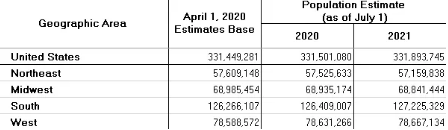
https://www2.census.gov/programs-surveys/popest/tables/2020-2021/state/totals/

In [30]:
import pandas as pd

# 1) 각 지역별 인구 (Census 2021 추정치)
raw_pop = {
    1: 57_159_838,   # Northeast
    2: 68_841_444,   # Midwest
    3: 127_225_329,  # South (max)
    4: 78_667_134    # West
}
total_pop = sum(raw_pop.values())

# 2) 원시 비율 계산
raw_share = {r: p / total_pop for r, p in raw_pop.items()}
max_share = raw_share[3]  # South

# 3) 0~0.07 로 선형 축소
scaled_share = {r: raw_share[r] / max_share * 0.07 for r in raw_share}

# 4) 매핑 함수 (기타 지역은 HC 평균값 0.02)
def map_region(code):
    try:
        code = float(code)
    except (ValueError, TypeError):
        return 0.02
    return scaled_share.get(int(code), 0.02)

# 5) 적용
df = pd.read_csv("./psid_core_cols.csv")
df["REGION_POPULATION_RELATIVE"] = df["GEO_REGION"].apply(map_region)

# 6) 저장
df.to_csv("./psid_core_cols.csv", index=False)
print("✅ 완료: 'psid_core_cols.csv'에 REGION_POPULATION_RELATIVE 추가됨")


✅ 완료: 'psid_core_cols.csv'에 REGION_POPULATION_RELATIVE 추가됨


### 3.2.4 DAYS_EMPLOYED 

In [31]:
import pandas as pd

# 원본 파일 경로
IN_PATH  = "./PSIDSHELF_1968_2021_LONG.csv"
# 결과물 저장 경로
OUT_PATH = "./days_employed.csv"

# 불러올 컬럼 리스트
USE_COLS = ["ID", "YEAR", "EMP_WORK_MM"]

# 1) chunk 단위로 읽어서 필요한 컬럼만 추출 & 저장
reader = pd.read_csv(
    IN_PATH,
    usecols=USE_COLS,
    chunksize=200_000,    # 메모리 상황에 따라 조절
    dtype={"ID": int, "YEAR": int, "EMP_WORK_MM": float}  # 타입 지정하면 속도↑
)

# 첫 청크는 헤더 포함해서 쓰고, 그 이후는 append 방식
first = True
for chunk in reader:
    if first:
        chunk.to_csv(OUT_PATH, index=False, mode="w")
        first = False
    else:
        chunk.to_csv(OUT_PATH, index=False, header=False, mode="a")

print(f"✅ 필요한 컬럼만 추출 완료 → '{OUT_PATH}'")


✅ 필요한 컬럼만 추출 완료 → './days_employed.csv'


In [32]:
import pandas as pd

# 1) ID 목록 불러오기
ids = pd.read_csv("./id_data.csv", usecols=["ID"])["ID"]

# 2) days_employed 전체 파일 불러오기
df_days = pd.read_csv("./days_employed.csv")

# 3) ID 기준으로 필터링
df_filtered = df_days[df_days["ID"].isin(ids)]

# 4) 결과 저장
df_filtered.to_csv("./days_employed_filtered.csv", index=False)

print(f"Filtered rows: {len(df_filtered):,}")

Filtered rows: 345,996


#### ID별로 근속년수 컬럼 추가

In [33]:
import pandas as pd

# 1) 데이터 불러오기 & 정렬
df = pd.read_csv("./days_employed_filtered.csv")  # ID, YEAR, EMP_WORK_MM 포함
df = df.sort_values(["ID", "YEAR"]).reset_index(drop=True)

# 2) 근속 년수 컬럼 초기화
df["tenure_years"] = 0

# 3) ID별로 순회하며 연속 근속 년수 계산
for pid, grp in df.groupby("ID", sort=False):
    prev_year   = None
    prev_emp    = 0
    prev_tenure = 0
    for idx, row in grp.iterrows():
        year = row["YEAR"]
        emp  = row["EMP_WORK_MM"]
        if emp == 1:
            if prev_emp == 1 and prev_year is not None:
                # 연속 취업 중 → 지난 조사 대비 연도 차이만큼 더하기
                tenure = prev_tenure + (year - prev_year)
            else:
                # 새로 취업 시작 → 1년부터 시작
                tenure = 1
        else:
            # 무직 시 근속 초기화
            tenure = 0

        df.at[idx, "tenure_years"] = tenure
        prev_year   = year
        prev_emp    = emp
        prev_tenure = tenure

# 4) 결과 확인 및 저장
print(df[["ID", "YEAR", "EMP_WORK_MM", "tenure_years"]].head(20))
df.to_csv("./psid_tenure_years.csv", index=False)


      ID  YEAR  EMP_WORK_MM  tenure_years
0   4007  1968          NaN             0
1   4007  1969          NaN             0
2   4007  1970          NaN             0
3   4007  1971          NaN             0
4   4007  1972          NaN             0
5   4007  1973          NaN             0
6   4007  1974          NaN             0
7   4007  1975          NaN             0
8   4007  1976          NaN             0
9   4007  1977          NaN             0
10  4007  1978          NaN             0
11  4007  1979          1.0             1
12  4007  1980          NaN             0
13  4007  1981          NaN             0
14  4007  1982          1.0             1
15  4007  1983          1.0             2
16  4007  1984          1.0             3
17  4007  1985          1.0             4
18  4007  1986          1.0             5
19  4007  1987          1.0             6


In [34]:
import pandas as pd

# 1) 데이터 불러오기
df = pd.read_csv("./psid_tenure_years.csv")  # ID, YEAR, EMP_WORK_MM, tenure_years 포함

# 2) ID별 총 근속 기간(years)을 계산하는 함수
def calc_total_tenure(group):
    total = 0
    in_segment = False
    start_year = None
    prev_year = None

    # 연도 순으로 순회
    for year, emp in zip(group["YEAR"], group["EMP_WORK_MM"]):
        if emp == 1:
            if not in_segment:
                # 새 근속 구간 시작
                in_segment = True
                start_year = year
        else:
            if in_segment:
                # 근속 구간 종료 → 구간 길이만큼 합산
                total += (prev_year - start_year)
                in_segment = False
        prev_year = year

    # 마지막까지 근속 중이었다면 남은 구간 합산
    if in_segment:
        total += (prev_year - start_year)

    return total

# 3) 각 ID별로 calc_total_tenure 적용
total_years = (
    df
    .groupby("ID", sort=False)
    .apply(calc_total_tenure)
    .rename("total_tenure_years")
    .reset_index()
)

# 4) 원본 df와 병합
df = pd.merge(df, total_years, on="ID", how="left")

# 5) 결과 저장
df.to_csv("./psid_with_total_tenure.csv", index=False)

# 확인
print(df[["ID", "total_tenure_years"]].drop_duplicates().head())


       ID  total_tenure_years
0    4007                  23
42   4031                   0
84   4034                  17
126  4038                   4
168  4039                   0


In [35]:
import pandas as pd
import numpy as np

# ---------- 경로 ----------
CORE_PATH   = "./psid_core_cols.csv"
TENURE_PATH = "./psid_tenure_years.csv"
OUT_PATH    = "./psid_core_with_days_employed.csv"

# ---------- 파라미터 ----------
# HC 데이터셋과 동일하게 "미취업/불명"을 365243 으로 표기
SENTINEL = 365_243          # None 으로 두면 그냥 NaN 남김
DAYS_PER_YEAR = 365         # 필요 시 365.25 로 바꿔도 됨

# ---------- 1. 로드 ----------
core  = pd.read_csv(CORE_PATH)
ten   = pd.read_csv(TENURE_PATH, usecols=["ID", "YEAR", "tenure_years"])

# ---------- 2. dtype 정리 ----------
# 수치형으로 강제 변환 (문자 → 숫자)
core["ID"]  = pd.to_numeric(core["ID"], errors="coerce").astype("Int64")
core["YEAR"]= pd.to_numeric(core["YEAR"], errors="coerce").astype("Int64")

ten["ID"]   = pd.to_numeric(ten["ID"], errors="coerce").astype("Int64")
ten["YEAR"] = pd.to_numeric(ten["YEAR"], errors="coerce").astype("Int64")
ten["tenure_years"] = pd.to_numeric(ten["tenure_years"], errors="coerce")

# ---------- 3. 머지 ----------
merged = core.merge(ten, on=["ID","YEAR"], how="left", validate="m:1")

# ---------- 4. DAYS_EMPLOYED 계산 ----------
# tenure_years > 0 이면 음수 일수, 아니면 sentinel
has_tenure = merged["tenure_years"].notna() & (merged["tenure_years"] > 0)

merged["DAYS_EMPLOYED"] = np.where(
    has_tenure,
    - (merged["tenure_years"] * DAYS_PER_YEAR).round().astype("Int64"),
    SENTINEL if SENTINEL is not None else np.nan
)

# ---------- 5. 정리 ----------
merged = merged.drop(columns=["tenure_years"])  # 중간열 제거

# ---------- 6. 저장 ----------
merged.to_csv(OUT_PATH, index=False)

# ---------- 7. 요약 출력 ----------
print("저장 완료:", OUT_PATH)
print("DAYS_EMPLOYED 분포(상위 10):")
print(merged["DAYS_EMPLOYED"].value_counts(dropna=False).head(10))


저장 완료: ./psid_core_with_days_employed.csv
DAYS_EMPLOYED 분포(상위 10):
DAYS_EMPLOYED
 365243    5557
-1095      1443
-1825      1348
-365       1269
-2555      1072
-3285       920
-4015       680
-4745       552
-5475       520
-6205       460
Name: count, dtype: int64


## 3.3 PSID 데이터셋 전처리 : 단순 수치 변경
- DAYS_BIRTH, AMT_INCOME_TOTAL 등 : 단순 수치 변환

### 3.3.1 단순 조작 변수를 전처리

In [39]:
# ---------------------------------------------------------------
#  psid_core_cols  ➜  HC15 매핑 (추가 컬럼 포함)   v3
# ---------------------------------------------------------------
import pandas as pd
import numpy as np

IN_PATH  = "psid_core_cols.csv"
OUT_PATH = "psid_hc_mapped_base.csv"

df = pd.read_csv(IN_PATH)

# ────────────────────────────── 1. 기본 파생 ─────────────────────────────────
df["DAYS_BIRTH"]       = -df["DEMO_AGE_GEN"] * 365                 # 음수(생일~조사일)
df["AMT_INCOME_TOTAL"] = df["EARN_TOT_ND"]                         # 개인소득
df["CNT_CHILDREN"]     = df["FAM_SIZE_CHI"]
df["CNT_FAM_MEMBERS"]  = df["FAM_SIZE"]

# ────────────────────────────── 2. 범주 매핑 ────────────────────────────────
df["CODE_GENDER"] = df["DEMO_SEX"].map({1: "M", 2: "F"}).fillna("U")

fam_map = {1: "Married", 2: "Separated", 3: "Single",
           4: "Widow", 5: "Divorced", 6: "Civil marriage"}
df["NAME_FAMILY_STATUS"]  = df["FAM_MARSTAT"].map(fam_map).fillna("Unknown")

edu_map = {1: "Higher education", 2: "Secondary / secondary special",
           3: "Incomplete higher", 4: "Lower secondary", 5: "Academic degree"}
df["NAME_EDUCATION_TYPE"] = df["EDU_LEVEL"].map(edu_map).fillna("Unknown")

# ────────────────────────────── 3. 소유 플래그 ───────────────────────────────
yn = {0: "N", 1: "Y"}

df["FLAG_OWN_CAR"] = (
    (df.get("WLTH_VEHI_NET_ND", 0) > 0).astype(int).map(yn)
)

df["FLAG_OWN_REALTY"] = (
    (df.get("HOME_STAT").fillna(0).astype(int) == 1).astype(int).map(yn)
)

# ────────────────────────────── 4. 재무 파생 ────────────────────────────────
# 4-1) 총 부채·비율
df["BUR_DEBT_SUM"]   = df["WLTH_TOT_DEB_ND"]
df["BUR_DEBT_RATIO"] = np.where(
    df["WLTH_TOT_ASS_RD"] > 0,
    df["WLTH_TOT_DEB_RD"] / df["WLTH_TOT_ASS_RD"],
    np.nan
)

# 4-2) AMT_CREDIT (대출 원금 proxy) – 총 부채(비반올림)
df["AMT_CREDIT"] = df["WLTH_TOT_DEB_ND"]

# 4-3) AMT_ANNUITY 계산 (모기지 vs 임차 vs 완납)
# ─── 주거 유형 분기 ──────────────────────────────
own_mort = (df["HOME_STAT"] == 1) & (df["WLTH_HOME_DEB_ND"] > 0)   # 자가 + 모기지
own_free = (df["HOME_STAT"] == 1) & (df["WLTH_HOME_DEB_ND"] == 0)  # 자가 + 완납
rent     = (df["HOME_STAT"] != 1)                                  # 임차

# ─── (1) 모기지 가구: 잔액·금리·만기로 연 상환액 역산 ──────
def annuity_from_balance(P, r=0.04, n=20):
    if P <= 0:
        return 0.0
    pm = r / (1 - (1 + r) ** -n)      # 월 상환계수
    return P * pm * 12                # 연환산

df["AMT_ANNUITY"] = 0.0                                   # 초기화
df.loc[own_mort, "AMT_ANNUITY"] = (
    df.loc[own_mort, "WLTH_HOME_DEB_ND"].apply(annuity_from_balance)
)

# ─── (2) 임차 가구: 연 임차료 그대로 사용 ──────────────────
df.loc[rent, "AMT_ANNUITY"] = df.loc[rent, "EXPN_HOUS_TOT_ND"]

# ─── (3) 자가 완납: 상환액 0 ───────────────────────────────
df.loc[own_free, "AMT_ANNUITY"] = 0.0


# 4-4) 파생 비율
df["CREDIT_INCOME_RATIO"]   = np.where(
    df["FINC_TOT_ND"] > 0,
    df["WLTH_TOT_DEB_ND"] / df["FINC_TOT_ND"],
    np.nan
)
df["ANNUITY_INCOME_RATIO"]  = np.where(
    df["FINC_TOT_ND"] > 0,
    df["AMT_ANNUITY"] / df["FINC_TOT_ND"],
    np.nan
)
df["ANNUITY_CREDIT_RATIO"]  = np.where(
    df["WLTH_TOT_DEB_ND"] > 0,
    df["AMT_ANNUITY"] / df["WLTH_TOT_DEB_ND"],
    np.nan
)

# ────────────────────────────── 5. 최종 열 구성 ────────────────────────────
hc_cols = [
    # 기본 Key
    "ID", "YEAR",

    # 개인·가구
    "CODE_GENDER","DAYS_BIRTH","EMP_DUR_YEARS",
    "CNT_CHILDREN","CNT_FAM_MEMBERS",
    "NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
    "OCCUPATION_TYPE",

    # 소유플래그
    "FLAG_OWN_REALTY","FLAG_OWN_CAR",

    # 재무 원본
    "AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY",
    "BUR_DEBT_SUM","BUR_DEBT_RATIO",
    "CREDIT_INCOME_RATIO","ANNUITY_INCOME_RATIO","ANNUITY_CREDIT_RATIO"
]

missing = [c for c in hc_cols if c not in df.columns]
if missing:
    raise ValueError(f"필수 컬럼 누락: {missing}")

df[hc_cols].to_csv(OUT_PATH, index=False)
print(f"✅ '{OUT_PATH}' 저장 완료  (rows={len(df):,})")


✅ 'psid_hc_mapped_base.csv' 저장 완료  (rows=16,455)


### 3.3.2 EXT 제외 종합 파일 생성
- REGION_POPULATION_RELATIVE, NAME_INCOME_TYPE, OCCUPATION_TYPE 첨부

In [40]:
base = pd.read_csv('./psid_hc_mapped_base.csv')
income = pd.read_csv('./income_mapping_subset.csv')
core = pd.read_csv('./psid_core_with_days_employed.csv')

base['NAME_INCOME_TYPE'] = income['NAME_INCOME_TYPE']
base['OCCUPATION_TYPE'] = core['OCCUPATION_TYPE']
base['REGION_POPULATION_RELATIVE'] = core['REGION_POPULATION_RELATIVE']
base['DAYS_EMPLOYED'] = core['DAYS_EMPLOYED']


base.loc[df["OCCUPATION_TYPE"] == "Other", "OCCUPATION_TYPE"] = pd.NA

base.to_csv('./result.csv')

print("✅ result.csv 결과 저장 완료")

✅ result.csv 결과 저장 완료


## 3.4 PSID 데이터셋 전처리 : 프록시 생성
- EXT_SOURCE_01,2,3 : Proxy 생성 필요

### 3.4.1 EXT_SOURCE_1 생성

In [53]:
### 3.4.1 EXT_SOURCE_1 생성# EXT_SOURCE_1 → EXT_PROXY_1
# - ElasticNetCV (logit link) + 도메인 가중치
# - sklearn 버전 호환: OHE(sparse_output/sparse), RMSE 계산, sample_weight 수동 처리
# - 가중치 길이 일치 보장

import os, warnings, joblib
import numpy as np, pandas as pd
from scipy.special import expit, logit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, QuantileTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# ── 경로 ─────────────────────────────────────────────────────────────
HC_PATH   = "./home-credit-default-risk/application_train.csv"
PSID_PATH = "./result.csv"         # PSID 매핑된 파일
OUT_PATH  = "./psid_with_ext_proxy1.csv"
MODEL_DIR = "./models"; os.makedirs(MODEL_DIR, exist_ok=True)
TARGET    = "EXT_SOURCE_1"

# ── 사용 변수(양쪽 교집합만 사용) ────────────────────────────────────
HC_NUM_ALL = [
    "DAYS_BIRTH","DAYS_EMPLOYED","AMT_INCOME_TOTAL",
    "CNT_CHILDREN","CNT_FAM_MEMBERS","REGION_POPULATION_RELATIVE"
]
HC_CAT_ALL = [
    "CODE_GENDER","NAME_FAMILY_STATUS","NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE","OCCUPATION_TYPE",
    "FLAG_OWN_REALTY","FLAG_OWN_CAR"
]

def ohe_compat(drop="first", handle_unknown="ignore"):
    # sklearn 1.2-1.4: sparse_output, 그 이전: sparse
    try:
        return OneHotEncoder(drop=drop, handle_unknown=handle_unknown, sparse_output=False)
    except TypeError:
        return OneHotEncoder(drop=drop, handle_unknown=handle_unknown, sparse=False)

def clean_cats(df, cat_cols):
    for c in cat_cols:
        if c in df.columns:
            df[c] = df[c].astype("string").fillna("Missing").str.strip()
    return df

def rmse_compat(y_true, y_pred):
    # 오래된 sklearn은 squared 인자를 지원하지 않음
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))

def robust_clip01(x):
    return np.clip(x, 0.0, 1.0)

# ── 데이터 로드 ─────────────────────────────────────────────────────
hc   = pd.read_csv(HC_PATH)
psid = pd.read_csv(PSID_PATH)

# 양쪽에 모두 있는 컬럼만 선택
num_cols = [c for c in HC_NUM_ALL if c in hc.columns and c in psid.columns]
cat_cols = [c for c in HC_CAT_ALL if c in hc.columns and c in psid.columns]

hc   = clean_cats(hc, cat_cols)
psid = clean_cats(psid, cat_cols)

use_cols = num_cols + cat_cols + [TARGET]
hc_train = hc.loc[hc[TARGET].notna(), use_cols].copy()

# 수치 결측: 중앙값, 범주 결측: "Missing"
for c in num_cols:
    med = hc_train[c].median(skipna=True)
    hc_train[c] = hc_train[c].fillna(med)
for c in cat_cols:
    hc_train[c] = hc_train[c].fillna("Missing")

X = hc_train[num_cols + cat_cols]
y = hc_train[TARGET].astype(float).clip(0, 1)

# ── 도메인 가중치: PSID 분포에 가까울수록 가중 ↑ ─────────────────────
def make_domain_weights(hc_df, psid_df, num_cols, cat_cols):
    hc_s = hc_df[num_cols + cat_cols].copy()
    ps_s = psid_df[num_cols + cat_cols].copy()

    for c in num_cols:
        hc_s[c] = hc_s[c].fillna(hc_s[c].median(skipna=True))
        ps_s[c] = ps_s[c].fillna(ps_s[c].median(skipna=True))
    for c in cat_cols:
        hc_s[c] = hc_s[c].fillna("Missing").astype("string")
        ps_s[c] = ps_s[c].fillna("Missing").astype("string")

    pre = ColumnTransformer([
        ("num_q", QuantileTransformer(n_quantiles=200, output_distribution="normal",
                                     subsample=2_000_000, random_state=42), num_cols),
        ("cat",   ohe_compat(), cat_cols),
    ])
    Xh = pre.fit_transform(hc_s)
    Xp = pre.transform(ps_s)

    mu = Xp.mean(axis=0)
    sd = Xp.std(axis=0) + 1e-6
    z  = (Xh - mu) / sd
    dist = np.sqrt((z ** 2).sum(axis=1))          # 대각 공분산 가정의 마할라노비스 유사
    w = np.exp(-dist)                             # PSID 중심에 가까울수록 크다
    w = np.clip(w, 0.05, 20.0)
    w = w / w.mean()
    return pd.Series(w)  # 0..n-1 index

weights_all = make_domain_weights(hc, psid, num_cols, cat_cols)

# hc_train에 맞게 가중치 정렬(인덱스 기준 매칭)
# hc는 RangeIndex(0..n-1) → hc_train.index는 원본 행번호를 유지
pos = hc.index.get_indexer(hc_train.index)   # 각 행의 원본 위치 (없으면 -1)
weights = weights_all.iloc[np.where(pos >= 0, pos, 0)]  # -1 방어
weights = np.asarray(weights, dtype=np.float64)
# 길이 보정 안전장치
if len(weights) != len(hc_train):
    weights = weights_all.iloc[:len(hc_train)].to_numpy()
weights = weights / weights.mean()

# ── 전처리(수동) ────────────────────────────────────────────────────
preproc = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", ohe_compat(), cat_cols),
])

X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
    X, y, weights, test_size=0.2, random_state=42
)

Xtr_t = preproc.fit_transform(X_tr)
Xval_t = preproc.transform(X_val)

# 타깃 로그릿 변환 후 회귀
z_tr = logit(np.clip(y_tr, 1e-6, 1-1e-6))

reg = ElasticNetCV(
    l1_ratio=[.1,.3,.5,.7,.9,.95,.99,1.0],
    alphas=np.logspace(-4, 0, 40),
    cv=5,
    n_jobs=-1,
    max_iter=100_000,
    random_state=42
)
reg.fit(Xtr_t, z_tr, sample_weight=w_tr)

# ── 검증 성능 ──────────────────────────────────────────────────────
z_hat = reg.predict(Xval_t)
y_hat = robust_clip01(expit(z_hat))

r2   = r2_score(y_val, y_hat)
mae  = mean_absolute_error(y_val, y_hat)
rmse = rmse_compat(y_val, y_hat)
pear = float(np.corrcoef(y_val, y_hat)[0,1])
spear= float(pd.Series(y_val).corr(pd.Series(y_hat), method="spearman"))

print("\n=== Validation (HC holdout) ===")
print(f"R²       : {r2:.4f}")
print(f"MAE      : {mae:.5f}")
print(f"RMSE     : {rmse:.5f}")
print(f"Pearson  : {pear:.4f}")
print(f"Spearman : {spear:.4f}")
print(f"Pred rng : [{y_hat.min():.5f}, {y_hat.max():.5f}]")
print(f"Best α   : {reg.alpha_:.5g}")
print(f"l1_ratio : {reg.l1_ratio_}")
# 비제로 계수 개수
nnz = int(np.count_nonzero(reg.coef_))
print(f"Non‑zero coefficients: {nnz} / {reg.coef_.shape[0]}")

# ── PSID 예측 & 저장 ───────────────────────────────────────────────
ps_in = psid.copy()
for c in num_cols:
    ps_in[c] = ps_in[c].fillna(ps_in[c].median(skipna=True))
for c in cat_cols:
    ps_in[c] = ps_in[c].fillna("Missing").astype("string")

Xps_t = preproc.transform(ps_in[num_cols + cat_cols])
psid["EXT_PROXY_1"] = robust_clip01(expit(reg.predict(Xps_t)))

id_cols = [c for c in ["ID","YEAR","SK_ID_CURR"] if c in psid.columns]
save_cols = id_cols + ["EXT_PROXY_1"] + num_cols + cat_cols
psid[save_cols].to_csv(OUT_PATH, index=False)
print(f"\n✅ '{OUT_PATH}' 저장 완료 (rows = {len(psid):,})")

# 모델 번들 저장(전처리+회귀 파라미터 포함)
bundle = {
    "preproc": preproc,
    "reg": reg,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "target": "EXT_PROXY_1",
    "alpha": reg.alpha_,
    "l1_ratio": reg.l1_ratio_,
}
model_path = os.path.join(MODEL_DIR, "ext_proxy1_bundle.joblib")
joblib.dump(bundle, model_path)
print("✅ 모델 번들 저장:", model_path)



=== Validation (HC holdout) ===
R²       : 0.4777
MAE      : 0.12024
RMSE     : 0.15281
Pearson  : 0.6927
Spearman : 0.0093
Pred rng : [0.14228, 0.89212]
Best α   : 0.0001
l1_ratio : 0.1
Non‑zero coefficients: 41 / 44

✅ './psid_with_ext_proxy1.csv' 저장 완료 (rows = 16,455)
✅ 모델 번들 저장: ./models/ext_proxy1_bundle.joblib


### 3.4.2 EXT_SOURCE_2, 3 생성

In [104]:
# -*- coding: utf-8 -*-
# EXT_PROXY2_unsup / EXT_PROXY3_unsup 생성 + 설명력 리포트
# --------------------------------------------------------
# 사용법:
#   python make_ext_proxy_unsup.py
# 파일 경로만 바꿔서 실행하면 됩니다.

import os, re, json, warnings
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")
RANDOM_SEED = 42

# ───────── 사용자 경로 ─────────
INPUT_CSV  = "./result.csv"
OUT_CSV    = "./psid_with_ext2_ext3_unsup.csv"
OUT_DIR    = os.path.dirname(OUT_CSV) or "."
MODEL_DIR  = os.path.join(OUT_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

# ───────── 유틸 ─────────
def sigmoid(z):
    z = np.clip(z, -40, 40)
    return 1/(1+np.exp(-z))

def logit(p):
    p = np.clip(p, 1e-6, 1-1e-6)
    return np.log(p/(1-p))

def rank01(series_or_df):
    return series_or_df.rank(method="average")/(len(series_or_df)+1)

def choose_temperature(raw, target_spread=0.30,
                       grid=(0.5,0.7,1.0,1.3,1.6,2.0,2.5,3.0,4.0,5.0,6.0)):
    """
    raw: 평균0 / 표준편차1 정도로 정규화된 연속값(로짓 축 가정)
    sigmoid(T*raw)의 p90-p10이 target_spread에 가장 가까운 T를 고른다.
    """
    best_T, best_diff = 1.0, 1e9
    for T in grid:
        p = sigmoid(T*raw)
        spread = np.percentile(p,90) - np.percentile(p,10)
        diff = abs(spread - target_spread)
        if diff < best_diff:
            best_diff, best_T = diff, T
    return best_T

# ───────── 1) 로드 ─────────
df = pd.read_csv(INPUT_CSV, low_memory=False)
print(f"Loaded: {INPUT_CSV}  (rows={len(df):,}, cols={len(df.columns):,})")

# ───────── 2) 위험 신호 선택 ─────────
# 모두 "값 ↑ ⇒ 위험 ↑" 방향으로 만들기
base_cols = [
    "BUR_DEBT_RATIO",        # 부채비율
    "CREDIT_INCOME_RATIO",   # 신용/소득 비율
    "ANNUITY_INCOME_RATIO",  # 연금/소득 비율
    "ANNUITY_CREDIT_RATIO",  # 연금/신용 비율
    "BUR_DEBT_SUM",          # 부채 총액
    "AMT_INCOME_TOTAL",      # 총소득
    "DAYS_EMPLOYED",         # 고용 일수(음수=재직)
    "DAYS_BIRTH",            # 출생일수(음수)
    "AMT_CREDIT",            # 신용액
    "AMT_ANNUITY",           # 연금액
    "CNT_CHILDREN",          # 자녀 수
    "CNT_FAM_MEMBERS",       # 가족 구성원 수
    "REGION_POPULATION_RELATIVE",  # 지역 인구 상대값
]

present = [c for c in base_cols if c in df.columns]
missing = [c for c in base_cols if c not in df.columns]
if missing:
    print("⚠️ 누락 컬럼:", missing)

imp = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imp.fit_transform(df[present]), columns=present, index=df.index)

# 파생 위험 신호 구성
signals = {}

def add_sig(name, arr):
    signals[name] = pd.Series(arr, index=df.index)

# 원 신호들: 값 크게 → 위험↑ (이미 그 성격이면 그대로 사용)
if "BUR_DEBT_RATIO" in X_imp:        add_sig("BUR_DEBT_RATIO",        X_imp["BUR_DEBT_RATIO"].values)
if "CREDIT_INCOME_RATIO" in X_imp:   add_sig("CREDIT_INCOME_RATIO",   X_imp["CREDIT_INCOME_RATIO"].values)
if "ANNUITY_INCOME_RATIO" in X_imp:  add_sig("ANNUITY_INCOME_RATIO",  X_imp["ANNUITY_INCOME_RATIO"].values)
if "ANNUITY_CREDIT_RATIO" in X_imp:  add_sig("ANNUITY_CREDIT_RATIO",  X_imp["ANNUITY_CREDIT_RATIO"].values)
if "BUR_DEBT_SUM" in X_imp:          add_sig("BUR_DEBT_SUM",          X_imp["BUR_DEBT_SUM"].values)
if "AMT_CREDIT" in X_imp:            add_sig("AMT_CREDIT",            X_imp["AMT_CREDIT"].values)
if "AMT_ANNUITY" in X_imp:           add_sig("AMT_ANNUITY",           X_imp["AMT_ANNUITY"].values)
if "CNT_CHILDREN" in X_imp:          add_sig("CNT_CHILDREN",          X_imp["CNT_CHILDREN"].values)
if "CNT_FAM_MEMBERS" in X_imp:       add_sig("CNT_FAM",               X_imp["CNT_FAM_MEMBERS"].values)
if "REGION_POPULATION_RELATIVE" in X_imp:
    add_sig("REGION_POP_REL", X_imp["REGION_POPULATION_RELATIVE"].values)

# 역수형 신호: 값 작음(소득 낮음, 재직 짧음, 연령 낮음) ⇒ 위험↑ 로 변환
# 소득 낮음 → 위험↑
if "AMT_INCOME_TOTAL" in X_imp:
    low_income = 1.0/(X_imp["AMT_INCOME_TOTAL"].values + 1.0)
    add_sig("LOW_INCOME", low_income)

# 재직 짧음 → 위험↑
if "DAYS_EMPLOYED" in X_imp:
    emp_days = X_imp["DAYS_EMPLOYED"].values
    emp_years = np.where(emp_days < 0, -emp_days/365.0, 0.0)  # 재직이면 양수로 변환
    emp_short = 1.0/(emp_years + 0.25)
    add_sig("EMP_SHORT", emp_short)

# 연령 낮음 → 위험↑
if "DAYS_BIRTH" in X_imp:
    age_years = -X_imp["DAYS_BIRTH"].values/365.0
    younger = 1.0/(age_years + 0.1)
    add_sig("YOUNGER", younger)

S = pd.DataFrame(signals)
if S.shape[1] < 5:
    raise ValueError(f"유효 위험 신호가 부족합니다. 감지된 신호 수: {S.shape[1]}")

# ───────── 3) 정규화 표현 ─────────
S_rank = S.apply(rank01)  # 0~1 분위수 정규화
scaler = StandardScaler(with_mean=True, with_std=True)
S_std  = pd.DataFrame(scaler.fit_transform(S), columns=S.columns, index=S.index)

# ───────── 4) EXT_PROXY2_unsup ─────────
# PC1 절대 로딩을 가중치로 → 전체 신호 사용
pca = PCA(n_components=min(3, S.shape[1]), random_state=RANDOM_SEED)
pca.fit(S_std)
pc1 = pd.Series(np.abs(pca.components_[0]), index=S.columns)
w2  = pc1 / pc1.sum()

raw2   = (S_rank * w2).sum(axis=1)
raw2_z = (raw2 - raw2.mean())/(raw2.std(ddof=0)+1e-9)
T2     = choose_temperature(raw2_z.values, target_spread=0.30)
ext2   = sigmoid(T2 * raw2_z)
ext2_rank = raw2.rank(method="average")/(len(raw2)+1)

# ───────── 5) EXT_PROXY3_unsup ─────────
# 0.7*PC1 + 0.3*PC2 혼합 → 상위 K개(기본 8개)만 사용해 희소화, 분산 확대
if pca.n_components_ >= 2:
    pc2 = pd.Series(np.abs(pca.components_[1]), index=S.columns)
    w_mix = 0.7*pc1 + 0.3*pc2
else:
    w_mix = pc1.copy()

K = min(8, len(w_mix))
topk = w_mix.sort_values(ascending=False).head(K)
w3 = topk / topk.sum()

raw3   = (S_rank[w3.index] * w3).sum(axis=1)
raw3_z = (raw3 - raw3.mean())/(raw3.std(ddof=0)+1e-9)
T3     = choose_temperature(raw3_z.values, target_spread=0.33)
ext3   = sigmoid(T3 * raw3_z)
ext3_rank = raw3.rank(method="average")/(len(raw3)+1)

# ───────── 6) 결과 병합 & 저장 ─────────
out = df.copy()
out["EXT_PROXY2_unsup"]       = ext2
out["EXT_PROXY2_unsup_rank"]  = ext2_rank
out["EXT_PROXY3_unsup"]       = ext3
out["EXT_PROXY3_unsup_rank"]  = ext3_rank

# PD_common 이 있다면 단순 로짓결합도 함께 저장(α=β=1, 이후 튜닝 가능)
if "PD_common" in out.columns:
    out["EXT_PROXY2_unsup_plus"] = sigmoid(logit(out["PD_common"].values) + logit(out["EXT_PROXY2_unsup"].values))
    out["EXT_PROXY3_unsup_plus"] = sigmoid(logit(out["PD_common"].values) + logit(out["EXT_PROXY3_unsup"].values))

out.to_csv(OUT_CSV, index=False)
print(f"✅ 저장 완료 → {OUT_CSV}  (rows={len(out):,})")
print(f"   T2={T2:.3f}, 사용 신호수={len(w2)} | T3={T3:.3f}, 상위 K={len(w3)}")

# ───────── 7) 설명력/상관 리포트 ─────────
def stats(arr):
    return dict(
        min=float(np.min(arr)),
        p10=float(np.percentile(arr,10)),
        median=float(np.median(arr)),
        p90=float(np.percentile(arr,90)),
        max=float(np.max(arr)),
        spread_p90_p10=float(np.percentile(arr,90)-np.percentile(arr,10)),
        unique=int(np.unique(np.round(arr,6)).size)
    )

# (A) 두 점수의 분포 요약
rep = {
    "rows": int(len(df)),
    "signals_used": list(S.columns),
    "EXT_PROXY2_unsup": {**stats(ext2), "T": float(T2), "K_features": int(len(w2))},
    "EXT_PROXY3_unsup": {**stats(ext3), "T": float(T3), "K_features": int(len(w3)), "top_features": list(w3.sort_values(ascending=False).index)}
}

# (B) 신호 → 점수 다중선형 R² (설명력 진단)
signals_cols = list(S.columns)
X_all = S[signals_cols].fillna(S[signals_cols].median()).values

for pcol in ["EXT_PROXY2_unsup", "EXT_PROXY3_unsup"]:
    y = out[pcol].values
    lr = LinearRegression().fit(X_all, y)
    yhat = lr.predict(X_all)
    r2 = 1 - np.sum((y - yhat)**2) / np.sum((y - y.mean())**2)
    rep[f"R2_signals_to_{pcol}"] = float(r2)

# (C) 상관행렬(피어슨/스피어만)
corr_cols = ["EXT_PROXY2_unsup","EXT_PROXY3_unsup","EXT_PROXY2_unsup_rank","EXT_PROXY3_unsup_rank"] + signals_cols
corr_cols = [c for c in corr_cols if c in out.columns]

pearson  = out[corr_cols].corr(method="pearson")
spearman = out[corr_cols].corr(method="spearman")

pearson_path  = os.path.join(OUT_DIR, "corr_pearson_ext_unsup.csv")
spearman_path = os.path.join(OUT_DIR, "corr_spearman_ext_unsup.csv")
pearson.round(6).to_csv(pearson_path, index=True)
spearman.round(6).to_csv(spearman_path, index=True)
print(f"📄 상관표 저장: {pearson_path}, {spearman_path}")

# (D) JSON 리포트 저장
report_path = os.path.join(OUT_DIR, "ext_unsup_report.json")
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(rep, f, ensure_ascii=False, indent=2)
print(f"📄 리포트 저장: {report_path}")

# 요약 출력
print(json.dumps(rep, ensure_ascii=False, indent=2))


Loaded: ./result.csv  (rows=16,455, cols=23)
✅ 저장 완료 → ./psid_with_ext2_ext3_unsup.csv  (rows=16,455)
   T2=0.500, 사용 신호수=13 | T3=0.500, 상위 K=8
📄 상관표 저장: ./corr_pearson_ext_unsup.csv, ./corr_spearman_ext_unsup.csv
📄 리포트 저장: ./ext_unsup_report.json
{
  "rows": 16455,
  "signals_used": [
    "BUR_DEBT_RATIO",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "ANNUITY_CREDIT_RATIO",
    "BUR_DEBT_SUM",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "CNT_CHILDREN",
    "CNT_FAM",
    "REGION_POP_REL",
    "LOW_INCOME",
    "EMP_SHORT",
    "YOUNGER"
  ],
  "EXT_PROXY2_unsup": {
    "min": 0.23368062674207474,
    "p10": 0.3500167718333052,
    "median": 0.4904245192163233,
    "p90": 0.6683207115690429,
    "max": 0.8088701579870403,
    "spread_p90_p10": 0.31830393973573773,
    "unique": 15620,
    "T": 0.5,
    "K_features": 13
  },
  "EXT_PROXY3_unsup": {
    "min": 0.2196512556489501,
    "p10": 0.3491680498907998,
    "median": 0.49373424577633984,
    "p90": 0.6668141963861212,
 

### 3.4.3 EXT_SOURCE 컬럼 결합

In [107]:
data1 = pd.read_csv('./psid_with_ext_proxy1.csv')
data2 = pd.read_csv('./psid_with_ext2_ext3_unsup.csv')
result = pd.read_csv('./result.csv')

result['EXT_SOURCE_1'] = data1['EXT_PROXY_1']
result['EXT_SOURCE_2'] = data2['EXT_PROXY2_unsup']
result['EXT_SOURCE_3'] = data2['EXT_PROXY3_unsup']
result['AGE_YEARS'] = result['DAYS_BIRTH']
result['EMP_YEARS'] = result['DAYS_EMPLOYED']

result = result.drop(columns=['Unnamed: 0','DAYS_BIRTH','DAYS_EMPLOYED', 'YEAR'])
result.to_csv('./psid_target_data.csv', )

## 3.5 체납 예측 모델 → PSID 데이터셋 적용

### 3.5.1 체납 예측 모델 생성

In [217]:
import glob
import joblib
import pandas as pd
import numpy as np
import warnings
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

MODEL_DIR = "./"                          # hc_cb_fold*_seed*.pkl 이 있는 폴더
PSID_CSV   = "psid_target_data.csv"       # 예측용 PSID CSV (ID,YEAR 포함)
OUT_CSV    = "psid_with_prob.csv"         # 결과 출력

ID_COL    = "ID"        # ID 열 이름
YEAR_COL  = "YEAR"      # YEAR 열 이름
NUM_DUMMY = -999        # 수치형 결측 대체값
CAT_DUMMY = "Missing"   # 범주형 결측 대체값

# ── 1. PSID 로드 & ID·YEAR 분리 ────────────────────────────────
df_raw = pd.read_csv(PSID_CSV)
if ID_COL not in df_raw.columns:
    raise KeyError(f"{ID_COL} 컬럼을 찾을 수 없습니다.")
id_series = df_raw[ID_COL]
# YEAR는 쓰지 않으므로 드롭
df = df_raw.drop(columns=[c for c in [ID_COL, YEAR_COL, "Unnamed: 0"] if c in df_raw.columns])

# ── 2. 첫 모델 로드해서 feature order & cat_idx 추출 ────────────
model_paths = sorted(glob.glob(f"{MODEL_DIR}/hc_cb_fold*_seed*.pkl"))
if not model_paths:
    raise FileNotFoundError(f"모델 파일을 찾을 수 없습니다: {MODEL_DIR}")

# 첫 번째 모델 기준
first_model = joblib.load(model_paths[0])
feat_order  = first_model.feature_names_
cat_idx_set = set(first_model.get_cat_feature_indices())

print(f"🛈 첫 모델 기대 피처 수: {len(feat_order)}  (범주형: {len(cat_idx_set)})")

# 누락된 컬럼 체크
missing = [c for c in feat_order if c not in df.columns]
if missing:
    raise KeyError(f"PSID에 누락된 컬럼: {missing}")

# ── 3. PSID 컬럼 재정렬 & 결측 대체 ─────────────────────────────
# 순서대로 정렬
X = df[feat_order].copy()

# 수치형 / 범주형 분리해서 결측 대체 및 타입 변환
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = [c for i, c in enumerate(feat_order) if i in cat_idx_set]

# 수치형
X[num_cols] = X[num_cols].fillna(NUM_DUMMY).astype(float)
# 범주형
for c in cat_cols:
    X[c] = X[c].fillna(CAT_DUMMY).astype(str)

print("✅ PSID 데이터 재정렬·결측 대체 완료\n")

# ── 4. 개별 모델로 예측 → 리스트에 저장 ────────────────────────
all_probs = []
for model_path in model_paths:
    name = model_path.split("/")[-1].replace(".pkl","")
    print(f"▶ 예측 중: {name}")
    m = joblib.load(model_path)
    probs = m.predict_proba(X)[:,1]
    all_probs.append(probs)

# ── 5. 앙상블(평균) 확률 계산 ───────────────────────────────────
ensemble_prob = np.mean(all_probs, axis=0)

# ── 6. 결과 출력 CSV ──────────────────────────────────────────
out_df = pd.DataFrame({
    ID_COL: id_series,
    "prob": ensemble_prob
})
out_df.to_csv(OUT_CSV, index=False)
print(f"\n✅ 저장 완료 → {OUT_CSV}  (rows = {len(out_df):,})")
print(out_df["prob"].describe(percentiles=[.01,.1,.25,.5,.75,.9,.99]))


🛈 첫 모델 기대 피처 수: 23  (범주형: 7)
✅ PSID 데이터 재정렬·결측 대체 완료

▶ 예측 중: hc_cb_fold1_seed42
▶ 예측 중: hc_cb_fold1_seed52
▶ 예측 중: hc_cb_fold1_seed62
▶ 예측 중: hc_cb_fold1_seed72
▶ 예측 중: hc_cb_fold1_seed82
▶ 예측 중: hc_cb_fold2_seed42
▶ 예측 중: hc_cb_fold2_seed52
▶ 예측 중: hc_cb_fold2_seed62
▶ 예측 중: hc_cb_fold2_seed72
▶ 예측 중: hc_cb_fold2_seed82
▶ 예측 중: hc_cb_fold3_seed42
▶ 예측 중: hc_cb_fold3_seed52
▶ 예측 중: hc_cb_fold3_seed62
▶ 예측 중: hc_cb_fold3_seed72
▶ 예측 중: hc_cb_fold3_seed82
▶ 예측 중: hc_cb_fold4_seed42
▶ 예측 중: hc_cb_fold4_seed52
▶ 예측 중: hc_cb_fold4_seed62
▶ 예측 중: hc_cb_fold4_seed72
▶ 예측 중: hc_cb_fold4_seed82
▶ 예측 중: hc_cb_fold5_seed42
▶ 예측 중: hc_cb_fold5_seed52
▶ 예측 중: hc_cb_fold5_seed62
▶ 예측 중: hc_cb_fold5_seed72
▶ 예측 중: hc_cb_fold5_seed82

✅ 저장 완료 → psid_with_prob.csv  (rows = 16,455)
count    16455.000000
mean         0.042356
std          0.041891
min          0.002603
1%           0.004818
10%          0.009335
25%          0.015792
50%          0.028776
75%          0.052795
90%          0.090954
99% 

### 3.5.2 기준 체납 확률 분포 시각화

count    16455.000000
mean         0.042356
std          0.041891
min          0.002603
1%           0.004818
10%          0.009335
25%          0.015792
50%          0.028776
75%          0.052795
90%          0.090954
99%          0.214267
max          0.394332
Name: TARGET, dtype: float64


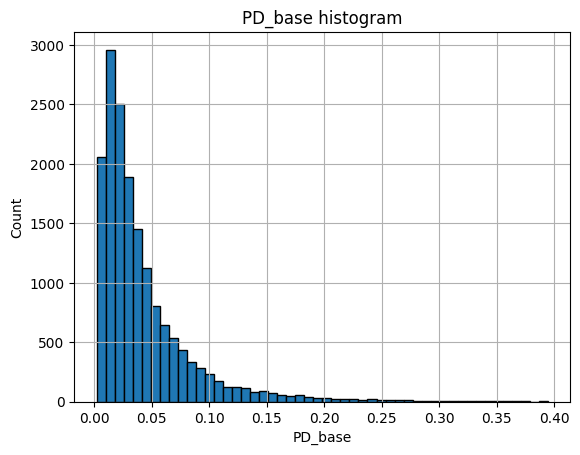

In [219]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv("psid_with_target_prob.csv")        # [ID, prob]

print(df["TARGET"].describe(percentiles=[.01,.1,.25,.5,.75,.9,.99]))
df["TARGET"].hist(bins=50, edgecolor="k")
plt.xlabel("PD_base"); plt.ylabel("Count"); plt.title("PD_base histogram")
plt.show()


# 4. 신용평가모델 B, C

## 4.1 자산 데이터 모델 (B) vs 자산 + 건강데이터 모델 (C) 제작 및 지표 비교

### 4.1.1 자산 데이터 모델 (B), 건강 데이터 모델 (C) 생성

In [2]:
import pandas as pd, numpy as np, os, re, json, warnings
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, roc_auc_score, average_precision_score
from sklearn.decomposition import PCA
from catboost import CatBoostRegressor, Pool
warnings.filterwarnings("ignore")

DATA_PATH = "./psid_with_target_prob.csv"
OUT_DIR   = "./health_model_outputs_v2"
os.makedirs(OUT_DIR, exist_ok=True)

def logit(p): p=np.clip(p,1e-6,1-1e-6); return np.log(p/(1-p))
def sigmoid(z): z=np.clip(z,-40,40); return 1/(1+np.exp(-z))

# ── 1) 로드 (compact 컬럼 + 건강 상세 파생 위해 원본도 허용) ──
df = pd.read_csv(DATA_PATH, low_memory=True)

# 필수
assert "TARGET" in df.columns, "TARGET 열이 필요합니다."
y = df["TARGET"].astype(float).values

AGE_COL = "DEMO_AGE_GEN" if "DEMO_AGE_GEN" in df.columns else ("DEMO_AGE_REP" if "DEMO_AGE_REP" in df.columns else None)
age = df[AGE_COL].astype(float).values if AGE_COL else np.full(len(df), 0)

# 핵심 재무
fin_cols = [c for c in ["FINC_TOT_RDF","WLTH_TOT_NET_RDF","WLTH_TOT_DEB_RDF","EXPN_TOT_RDF","EXPN_HLTH_TOT_RDF"] if c in df.columns]
# 핵심 건강
health_cols_base = [c for c in ["GHLTH_STAT","HOSP_ANY","HOSP_NUM","DEP_SCORE_TOT","ADL_SUM_TOT","IADL_SUM_TOT","BMI"] if c in df.columns]

# ── 2) 파생변수 ─────────────────────────────────────────────
# 의료비 부담률
if ("EXPN_HLTH_TOT_RDF" in df.columns) and ("FINC_TOT_RDF" in df.columns):
    df["HLTH_COST_RATIO"] = df["EXPN_HLTH_TOT_RDF"] / (df["FINC_TOT_RDF"].abs() + 1.0)
else:
    df["HLTH_COST_RATIO"] = np.nan

# ADL/IADL 플래그
if "ADL_SUM_TOT" in df.columns:
    df["ADL_FLAG"] = (df["ADL_SUM_TOT"].fillna(0) > 0).astype(int)
if "IADL_SUM_TOT" in df.columns:
    df["IADL_FLAG"] = (df["IADL_SUM_TOT"].fillna(0) > 0).astype(int)

# HEALTH_INDEX (개선: 질병/입원/기능지표에 가중)
health_cols = health_cols_base.copy()
if "HLTH_COST_RATIO" in df.columns: health_cols.append("HLTH_COST_RATIO")

imp_h = SimpleImputer(strategy="median")
H = imp_h.fit_transform(df[health_cols])
sc  = StandardScaler(with_mean=True, with_std=True)
H_std = sc.fit_transform(H)
pca = PCA(n_components=1, random_state=42).fit(H_std)
h_score = pca.transform(H_std).ravel()
healthy = sigmoid((h_score - h_score.mean())/(h_score.std()+1e-9))
health_risk = 1.0 - healthy
df["HEALTH_INDEX"] = health_risk

# 상호작용
df["HX_AGE"] = df["HEALTH_INDEX"] * age
if "HOSP_ANY" in df.columns:
    df["HOSP_AGE"] = df["HOSP_ANY"].fillna(0) * age
if "HLTH_COST_RATIO" in df.columns:
    df["HCR_AGE"] = df["HLTH_COST_RATIO"].fillna(0) * age

# 최종 피처 세트
features_fin = fin_cols
features_hlth = health_cols_base + ["HLTH_COST_RATIO","HEALTH_INDEX","ADL_FLAG","IADL_FLAG","HX_AGE","HOSP_AGE","HCR_AGE"]
features_hlth = [c for c in features_hlth if c in df.columns]

# ── 3) 재무만(EN) vs 재무+건강(CatBoost) 비교 ────────────────
# 재무만: ElasticNetCV (로짓 회귀)
from sklearn.linear_model import ElasticNetCV
Xf = df[features_fin].copy()
imp_f = SimpleImputer(strategy="median")
Xf_mat = imp_f.fit_transform(Xf)
scf = StandardScaler(with_mean=True, with_std=True)
Xf_mat = scf.fit_transform(Xf_mat)

y_log = logit(y)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_fin = np.zeros(len(df))

for tr, va in kf.split(Xf_mat):
    en = ElasticNetCV(l1_ratio=[0.1,0.3,0.5,0.7,0.9,1.0],
                      alphas=np.logspace(-4,0,40),
                      cv=5, max_iter=20000, tol=1e-5, n_jobs=1, random_state=42)
    en.fit(Xf_mat[tr], y_log[tr])
    oof_fin[va] = en.predict(Xf_mat[va])

p_fin = sigmoid(oof_fin)

# 재무+건강: CatBoostRegressor (로짓 예측)
features_all = features_fin + features_hlth
X_all = df[features_all]
imp_all = SimpleImputer(strategy="median")
X_all_mat = imp_all.fit_transform(X_all)

oof_aug = np.zeros(len(df))
for tr, va in kf.split(X_all_mat):
    train_pool = Pool(X_all_mat[tr], y_log[tr])
    valid_pool = Pool(X_all_mat[va], y_log[va])
    cb = CatBoostRegressor(
        depth=6, learning_rate=0.06, loss_function="RMSE",
        iterations=2000, l2_leaf_reg=6,
        random_seed=42, verbose=False
    )
    cb.fit(train_pool, eval_set=valid_pool)
    oof_aug[va] = cb.predict(X_all_mat[va])

p_aug = sigmoid(oof_aug)

### 4.1.2 모델 정량 지표(AUC 등) 및 세그먼트별 성능 비교

In [15]:
# ── 5) 서브그룹(Seniors, ARIP) ─────────────────────────────
def subgroup_stats(mask, label):
    idx = np.where(mask)[0]
    if len(idx) < 50:
        return {"group":label, "n":int(len(idx))}
    yg = y[idx]; pf=p_fin[idx]; pa=p_aug[idx]; yb = y_bin[idx]
    return {
        "group": label, "n": int(len(idx)),
        "R2_fin": r2_score(yg,pf), "R2_aug": r2_score(yg,pa),
        "AUC_fin": roc_auc_score(yb,pf), "AUC_aug": roc_auc_score(yb,pa),
        "PR_fin": average_precision_score(yb,pf), "PR_aug": average_precision_score(yb,pa)
    }

seniors = (age >= 50)
# ARIP: 자산 상위40 & 소득 하위40
wealth = df["WLTH_TOT_NET_RDF"].astype(float) if "WLTH_TOT_NET_RDF" in df.columns else pd.Series(np.nan, index=df.index)
income = df["FINC_TOT_RDF"].astype(float) if "FINC_TOT_RDF" in df.columns else pd.Series(np.nan, index=df.index)
w_rank = wealth.rank(method="average")/(len(df)+1)
i_rank = income.rank(method="average")/(len(df)+1)
arip = (w_rank >= 0.6) & (i_rank <= 0.4)

subs = []
subs.append(subgroup_stats(np.array([True]*len(df)), "All"))
subs.append(subgroup_stats(seniors, "Seniors(50+)"))
subs.append(subgroup_stats(arip, "ARIP"))
subs.append(subgroup_stats(seniors & arip, "Seniors∩ARIP"))
sub_df = pd.DataFrame(subs).round(4)

# ── 6) 저장 ────────────────────────────────────────────────
summary_tbl.to_csv(os.path.join(OUT_DIR, "summary_metrics.csv"), index=False)
ac.to_csv(os.path.join(OUT_DIR, "approval_curve_same_rate.csv"), index=False)
same_risk.to_csv(os.path.join(OUT_DIR, "approval_rate_at_same_risk.csv"), index=False)
sub_df.to_csv(os.path.join(OUT_DIR, "subgroup_metrics.csv"), index=False)

report = {
    "n": int(len(df)),
    "features_fin": features_fin,
    "features_health": features_hlth,
    "metrics": summary_tbl.to_dict(orient="records"),
    "approval_same_rate": ac.to_dict(orient="records"),
    "approval_same_risk": same_risk.to_dict(orient="records"),
    "subgroups": sub_df.to_dict(orient="records")
}
with open(os.path.join(OUT_DIR, "report.json"), "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(json.dumps(report, ensure_ascii=False, indent=2))
print(f"Saved → {OUT_DIR}")


{
  "n": 16455,
  "features_fin": [
    "FINC_TOT_RDF",
    "WLTH_TOT_NET_RDF",
    "WLTH_TOT_DEB_RDF",
    "EXPN_TOT_RDF",
    "EXPN_HLTH_TOT_RDF"
  ],
  "features_health": [
    "GHLTH_STAT",
    "HOSP_ANY",
    "HOSP_NUM",
    "DEP_SCORE_TOT",
    "ADL_SUM_TOT",
    "IADL_SUM_TOT",
    "BMI",
    "HLTH_COST_RATIO",
    "HEALTH_INDEX",
    "ADL_FLAG",
    "IADL_FLAG",
    "HX_AGE",
    "HOSP_AGE",
    "HCR_AGE"
  ],
  "metrics": [
    {
      "model": "Baseline(fin - EN)",
      "R2": -0.0504,
      "MAE": 0.0255,
      "RMSE": 0.0429,
      "Pearson": 0.2315,
      "Spearman": 0.3871,
      "AUC": 0.707,
      "PR_AUC": 0.3474
    },
    {
      "model": "Augmented(fin+health - CatBoost)",
      "R2": 0.385,
      "MAE": 0.0193,
      "RMSE": 0.0329,
      "Pearson": 0.6466,
      "Spearman": 0.6944,
      "AUC": 0.8533,
      "PR_AUC": 0.626
    }
  ],
  "approval_same_rate": [
    {
      "approval_rate": 0.3,
      "avg_risk_fin": 0.026583511135915904,
      "avg_risk_aug": 0.017

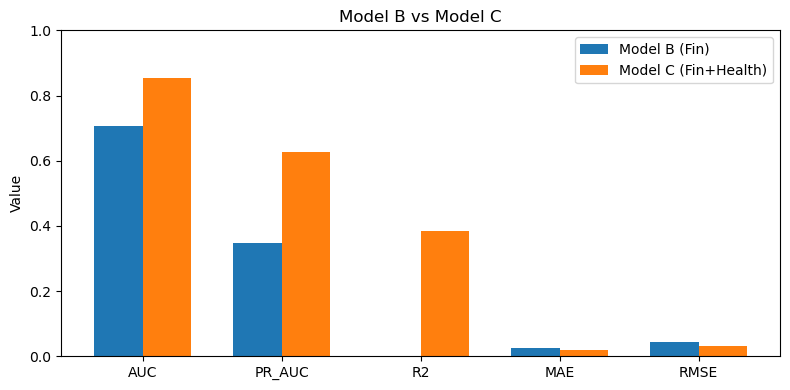

In [21]:
# 1) 지표 막대
m = pd.read_csv(os.path.join(OUT_DIR, "summary_metrics.csv"))
labels = ['AUC','PR_AUC','R2','MAE','RMSE']
b = m.loc[m['model']=='Baseline(fin - EN)', labels].values[0]
a = m.loc[m['model']=='Augmented(fin+health - CatBoost)', labels].values[0]

x = np.arange(len(labels)); w=0.35
plt.figure(figsize=(8,4))
plt.bar(x-w/2, b, w, label='Model B (Fin)')
plt.bar(x+w/2, a, w, label='Model C (Fin+Health)')
plt.xticks(x, labels); plt.ylim(0,1); plt.ylabel('Value')
plt.title('Model B vs Model C'); plt.legend(); plt.tight_layout(); plt.show()

## 4.2 모델 저장 및 변수 중요도 확인

### 4.2.1 모델 저장
- 재무 전용  → fin_model.pkl
- 재무+건강 → aug_model.pkl

두 개 별도로 joblib 번들로 저장합니다

In [9]:
import os, warnings, json, numpy as np, pandas as pd, joblib
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                             roc_auc_score, average_precision_score)
from sklearn.model_selection import KFold
from catboost import CatBoostRegressor, Pool
warnings.filterwarnings("ignore")

DATA_PATH = "./psid_with_target_prob.csv"
OUT_DIR   = "./health_model_outputs_v3"
os.makedirs(OUT_DIR, exist_ok=True)

def logit(p): p=np.clip(p,1e-6,1-1e-6); return np.log(p/(1-p))
def sigmoid(z): z=np.clip(z,-40,40); return 1/(1+np.exp(-z))

# ── 1. 데이터 로드 ─────────────────────────────────────────
df = pd.read_csv(DATA_PATH, low_memory=True)
y  = df["TARGET"].astype(float).values

AGE_COL = ("DEMO_AGE_GEN" if "DEMO_AGE_GEN" in df.columns else
           ("DEMO_AGE_REP" if "DEMO_AGE_REP" in df.columns else None))
age = df[AGE_COL].astype(float).values if AGE_COL else np.zeros(len(df))

fin_cols = [c for c in [
    "FINC_TOT_RDF","WLTH_TOT_NET_RDF","WLTH_TOT_DEB_RDF",
    "EXPN_TOT_RDF","EXPN_HLTH_TOT_RDF"] if c in df.columns]

health_base = [c for c in [
    "GHLTH_STAT","HOSP_ANY","HOSP_NUM","DEP_SCORE_TOT",
    "ADL_SUM_TOT","IADL_SUM_TOT","BMI"] if c in df.columns]

# ── 2. 파생 ────────────────────────────────────────────────
df["HLTH_COST_RATIO"] = (
    df["EXPN_HLTH_TOT_RDF"] / (df["FINC_TOT_RDF"].abs()+1)
    if {"EXPN_HLTH_TOT_RDF","FINC_TOT_RDF"} <= set(df.columns) else np.nan)

df["ADL_FLAG"]  = (df["ADL_SUM_TOT"].fillna(0)  > 0).astype(int) if "ADL_SUM_TOT"  in df.columns else 0
df["IADL_FLAG"] = (df["IADL_SUM_TOT"].fillna(0) > 0).astype(int) if "IADL_SUM_TOT" in df.columns else 0

health_cols = health_base + ["HLTH_COST_RATIO"]
imp_h = SimpleImputer(strategy="median").fit(df[health_cols])
H_std = StandardScaler().fit_transform(imp_h.transform(df[health_cols]))
pca   = PCA(n_components=1, random_state=42).fit(H_std)
h_score = pca.transform(H_std).ravel()
healthy = sigmoid((h_score - h_score.mean())/(h_score.std()+1e-9))
df["HEALTH_INDEX"] = 1 - healthy          # ↑ = 위험

df["HX_AGE"]  = df["HEALTH_INDEX"] * age
df["HOSP_AGE"] = df["HOSP_ANY"].fillna(0) * age if "HOSP_ANY" in df.columns else 0
df["HCR_AGE"]  = df["HLTH_COST_RATIO"].fillna(0) * age

# ── 3. 피처 목록 ───────────────────────────────────────────
features_fin  = fin_cols
features_hlth = (
    health_base + ["HLTH_COST_RATIO","HEALTH_INDEX",
                   "ADL_FLAG","IADL_FLAG","HX_AGE","HOSP_AGE","HCR_AGE"])
features_hlth = [c for c in features_hlth if c in df.columns]
features_all  = features_fin + features_hlth

# ── 4. 재무 전용 ElasticNetCV ─────────────────────────────
imp_fin = SimpleImputer(strategy="median").fit(df[features_fin])
sc_fin  = StandardScaler().fit(imp_fin.transform(df[features_fin]))
X_fin   = sc_fin.transform(imp_fin.transform(df[features_fin]))

en = ElasticNetCV(
    l1_ratio=[.1,.3,.5,.7,.9,1], alphas=np.logspace(-4,0,40),
    cv=5, max_iter=20000, random_state=42).fit(X_fin, logit(y))

# ── 5. 재무+건강 CatBoost ─────────────────────────────────
imp_all = SimpleImputer(strategy="median").fit(df[features_all])
X_all   = imp_all.transform(df[features_all])

cb = CatBoostRegressor(
    depth=6, learning_rate=0.06, iterations=2000,
    l2_leaf_reg=6, loss_function="RMSE",
    random_seed=42, verbose=False
).fit(Pool(X_all, logit(y)))

# ── 6. 모델 개별 저장 ─────────────────────────────────────
# (1) 재무 전용 번들
joblib.dump({
    "model": en,
    "imp":   imp_fin,
    "sc":    sc_fin,
    "features": features_fin
}, "fin_model.pkl")

# (2) 재무+건강 번들
joblib.dump({
    "model": cb,
    "imp_all": imp_all,
    "imp_h":   imp_h,
    "sc_h":    StandardScaler().fit(H_std),
    "pca":     pca,
    "features": features_all,
    "health_base": health_base
}, "aug_model.pkl")

print("✅ fin_model.pkl, aug_model.pkl 두 파일 저장 완료")


✅ fin_model.pkl, aug_model.pkl 두 파일 저장 완료


### 4.2.2 변수 중요도 확인

=== ElasticNet Feature Importance (절대계수 기준) ===
WLTH_TOT_NET_RDF     0.133695
EXPN_TOT_RDF         0.097924
FINC_TOT_RDF         0.095239
EXPN_HLTH_TOT_RDF    0.090369
WLTH_TOT_DEB_RDF     0.086697
dtype: float64


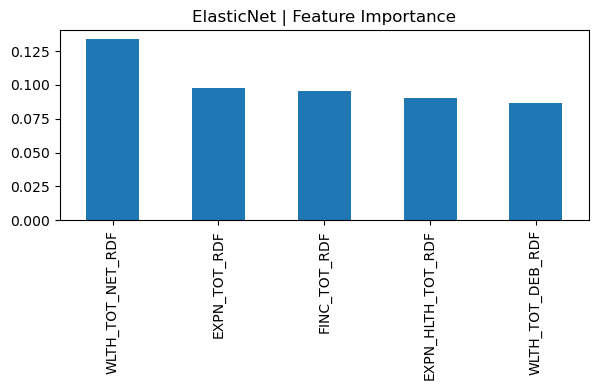

=== CatBoost Feature Importance ===
HX_AGE               18.467367
WLTH_TOT_DEB_RDF     14.624965
WLTH_TOT_NET_RDF     14.203793
FINC_TOT_RDF         11.454305
HEALTH_INDEX          8.495442
EXPN_TOT_RDF          7.197128
BMI                   6.225462
HCR_AGE               4.332135
EXPN_HLTH_TOT_RDF     2.827998
HLTH_COST_RATIO       2.310610
DEP_SCORE_TOT         2.001314
ADL_SUM_TOT           1.700091
GHLTH_STAT            1.638051
HOSP_AGE              1.564968
IADL_FLAG             1.058456
HOSP_NUM              0.721042
IADL_SUM_TOT          0.703319
ADL_FLAG              0.385214
HOSP_ANY              0.088339
dtype: float64


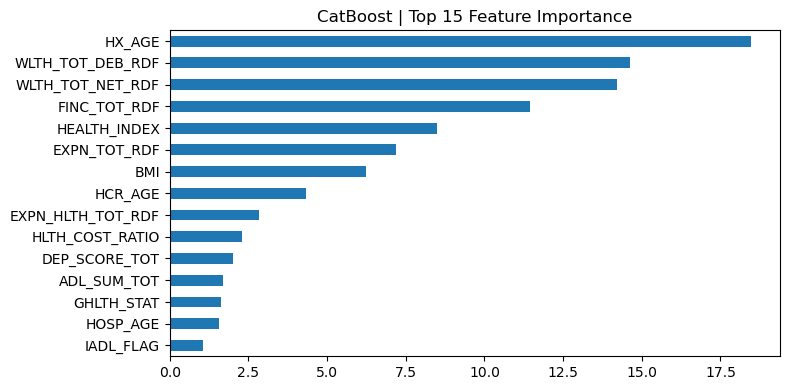

In [16]:
# ── 7) Feature Importance 출력 ─────────────────────────────────────────────

import matplotlib.pyplot as plt

# 1) ElasticNet 계수 기반 중요도
# 전체 데이터를 이용해 한 번 더 재학습하여 coef_를 뽑습니다.
en_full = ElasticNetCV(
    l1_ratio=[0.1,0.3,0.5,0.7,0.9,1.0],
    alphas=np.logspace(-4,0,40),
    cv=5, max_iter=20000, tol=1e-5, n_jobs=1, random_state=42
)
en_full.fit(Xf_mat, y_log)
coef = en_full.coef_

feat_imp_en = pd.Series(np.abs(coef), index=features_fin)
feat_imp_en = feat_imp_en.sort_values(ascending=False)

print("=== ElasticNet Feature Importance (절대계수 기준) ===")
print(feat_imp_en)

# (옵션) 시각화
plt.figure(figsize=(6,4))
feat_imp_en.plot.bar()
plt.title("ElasticNet | Feature Importance")
plt.tight_layout()
plt.show()


# 2) CatBoost 기반 중요도
# 전체 데이터를 이용해 CatBoost를 한 번 더 학습
train_pool_full = Pool(X_all_mat, y_log)
cb_full = CatBoostRegressor(
    depth=6, learning_rate=0.06, loss_function="RMSE",
    iterations=2000, l2_leaf_reg=6,
    random_seed=42, verbose=False
)
cb_full.fit(train_pool_full)

imp_cb = cb_full.get_feature_importance(train_pool_full, type="FeatureImportance")
feat_imp_cb = pd.Series(imp_cb, index=features_all)
feat_imp_cb = feat_imp_cb.sort_values(ascending=False)

print("=== CatBoost Feature Importance ===")
print(feat_imp_cb)

# (옵션) 시각화
plt.figure(figsize=(8,4))
feat_imp_cb.head(15).plot.barh()
plt.gca().invert_yaxis()
plt.title("CatBoost | Top 15 Feature Importance")
plt.tight_layout()
plt.show()


## 4.3 모델 (B) vs. 모델 (C) 정책효율 지표 비교 및 시각화

### 4.3.1 Risk-Target 기반 승인효율 비교

In [13]:
# ── 4) 지표 계산 ─────────────────────────────────────────────
def cont_metrics(y, p):
    return dict(
        R2=r2_score(y,p),
        MAE=mean_absolute_error(y,p),
        RMSE=float(np.sqrt(mean_squared_error(y,p))),
        Pearson=float(np.corrcoef(y,p)[0,1]),
        Spearman=float(pd.Series(y).corr(pd.Series(p), method="spearman"))
    )

from sklearn.metrics import mean_squared_error
res_fin = cont_metrics(y, p_fin)
res_aug = cont_metrics(y, p_aug)

thr = np.quantile(y, 0.80)
y_bin = (y >= thr).astype(int)
auc_fin = roc_auc_score(y_bin, p_fin); auc_aug = roc_auc_score(y_bin, p_aug)
pr_fin  = average_precision_score(y_bin, p_fin); pr_aug  = average_precision_score(y_bin, p_aug)

summary_tbl = pd.DataFrame([
    {"model":"Baseline(fin - EN)", **res_fin, "AUC":auc_fin, "PR_AUC":pr_fin},
    {"model":"Augmented(fin+health - CatBoost)", **res_aug, "AUC":auc_aug, "PR_AUC":pr_aug},
]).round(4)

# 승인곡선 (동일 승인율)
def approval_curve(y_true, p_pred, rates=(0.3,0.4,0.5,0.6,0.7)):
    order = np.argsort(p_pred); y_sorted = y_true[order]; rows=[]
    n=len(y_true)
    for r in rates:
        k = max(1, min(int(n*r), n))
        rows.append({"approval_rate": r, "avg_risk": float(y_sorted[:k].mean())})
    return pd.DataFrame(rows)

ac_fin = approval_curve(y, p_fin)
ac_aug = approval_curve(y, p_aug)
ac = ac_fin.merge(ac_aug, on="approval_rate", suffixes=("_fin","_aug"))
ac["risk_delta"] = ac["avg_risk_fin"] - ac["avg_risk_aug"]

# 동일 위험에서 승인률 비교
def approval_at_target_risk(y_true, p_pred, risk_targets=(0.015, 0.016, 0.017)):
    """
    예측확률 p_pred가 낮은 순으로 정렬했을 때,
    누적 평균 위험이 risk_target 이하가 되는 최대 승인비율을 계산.
    """
    order = np.argsort(p_pred)
    y_sorted = y_true[order].astype(float)
    n = len(y_sorted)
    # 누적평균: cumsum / (1..n)
    cum_mean = np.cumsum(y_sorted) / np.arange(1, n + 1)

    out = []
    for rt in risk_targets:
        # 누적평균이 목표 위험 이하인 마지막 인덱스
        idx = np.where(cum_mean <= rt)[0]
        if len(idx) == 0:
            appr = 0.0
        else:
            k = idx[-1] + 1  # 승인 고객 수
            appr = k / n
        out.append({"risk_target": float(rt), "approval_rate": float(appr)})
    return pd.DataFrame(out)

risk_targets = (0.02, 0.021, 0.022)
same_risk_fin = approval_at_target_risk(y, p_fin, risk_targets)
same_risk_aug = approval_at_target_risk(y, p_aug, risk_targets)
same_risk = same_risk_fin.merge(same_risk_aug, on="risk_target",
                                suffixes=("_fin","_aug"))
same_risk["approval_gain_pp"] = 100 * (same_risk["approval_rate_aug"] - same_risk["approval_rate_fin"])
same_risk.to_csv(os.path.join(OUT_DIR, "approval_rate_at_same_risk.csv"), index=False)
print(same_risk)

   risk_target  approval_rate_fin  approval_rate_aug  approval_gain_pp
0        0.020           0.070921           0.373625         30.270435
1        0.021           0.086296           0.406624         32.032817
2        0.022           0.110665           0.448800         33.813431


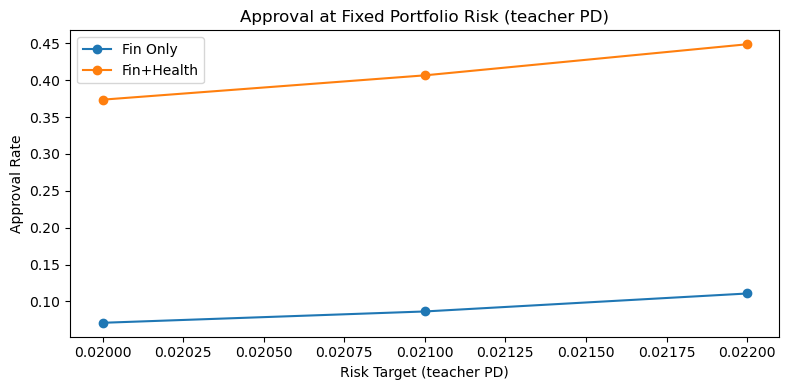

In [22]:
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt
OUT_DIR = "./health_model_outputs_v2"


# 2) 동일 위험(교사 PD 기준) 승인율
sr = pd.read_csv(os.path.join(OUT_DIR, "approval_rate_at_same_risk.csv"))
plt.figure(figsize=(8,4))
plt.plot(sr['risk_target'], sr['approval_rate_fin'], marker='o', label='Fin Only')
plt.plot(sr['risk_target'], sr['approval_rate_aug'], marker='o', label='Fin+Health')
plt.xlabel('Risk Target (teacher PD)'); plt.ylabel('Approval Rate')
plt.title('Approval at Fixed Portfolio Risk (teacher PD)'); plt.legend()
plt.tight_layout(); plt.show()


### 4.3.2 리스크 구간 (디사일)별 관측 연체율

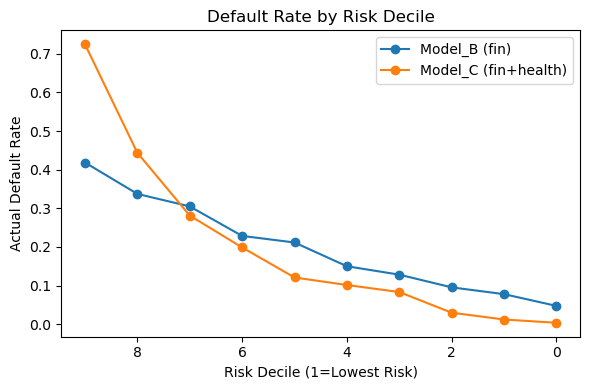

In [23]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load predictions and true labels
#    Adjust the path if needed to where your model outputs are saved.
#    Here, it's assumed you have saved y_true, p_fin, p_aug as numpy arrays in a .npz file:
#    np.savez('model_preds.npz', y_true=y, p_fin=p_fin, p_aug=p_aug)
data = np.load('./health_model_outputs_v2/model_preds.npz')
y_true = data['y_true']
p_fin = data['p_fin']
p_aug = data['p_aug']

# Convert true target to binary (default if above threshold)
# If y_true is continuous PD, threshold at your PD quantile (e.g., top 20%)
thr = np.quantile(y_true, 0.80)
y_bin = (y_true >= thr).astype(int)

# 2) Compute actual default rate by decile for both models
df = pd.DataFrame({
    'y': y_bin,
    'p_fin': p_fin,
    'p_aug': p_aug
})
df['decile_fin'] = pd.qcut(df['p_fin'], 10, labels=False) + 1
df['decile_aug'] = pd.qcut(df['p_aug'], 10, labels=False) + 1

# Group and calculate default rates
default_rate_fin = df.groupby('decile_fin')['y'].mean()
default_rate_aug = df.groupby('decile_aug')['y'].mean()

# 3) Plot default rate curves (low risk decile on left)
plt.figure(figsize=(6,4))
plt.plot(default_rate_fin.values, marker='o', label='Model_B (fin)')
plt.plot(default_rate_aug.values, marker='o', label='Model_C (fin+health)')
plt.gca().invert_xaxis()
plt.xlabel('Risk Decile (1=Lowest Risk)')
plt.ylabel('Actual Default Rate')
plt.title('Default Rate by Risk Decile')
plt.legend()
plt.tight_layout()
plt.show()